In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from tqdm import tqdm
import os, re, gc, warnings
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.stats as st
from adjustText import adjust_text
from statsmodels.stats.multitest import multipletests
from collections import Counter
from itertools import combinations, product
from functools import partial
from joblib import delayed, Parallel
from typing import Literal
import scikit_posthocs as sp
import statsmodels.api as sm
from statsmodels.stats.multicomp import MultiComparison
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

## Loading and Preprocessing datasets

Here, we will load our datasets, and preprocess for analysis. Data preparation would involve the following

- Loading datasets (`train` and `cytokine levels`)
- Metadata (`train_info` and `train_info2`)
- Load selected features from Elastic Net that are useful in predicting cytokine levels (obtained from Track 1)
- Obtain canonical kmers (kmers whose reverse complements are regarded to be similar)
- We will filter out kmers in train data that are not in selected kmers (canonical kmers)
- Merge all metadata to kmer dataframe and cytokine dataframes


In [2]:
def normalise_counts(X):
    """
    Normalises kmer counts using Centered Log Ratio (CLR)
    
    :param X: Pandas DataFrame | Numpy ndarray
    :returns CLR-normalised counts
    """
    logX = np.log1p(np.array(X))
    gm = np.mean(logX, axis=1, keepdims=True)
    norm_counts = logX - gm
    return norm_counts.astype(np.float32)

In [3]:
train = pd.read_parquet('../data/train_8kmer_all.parquet')
cytokine_df = pd.read_csv('../data/cytokine_profiles.csv')
train_info = pd.read_csv('../data/Train_Subjects.csv')
train_info2 = pd.read_csv('../data/Train.csv')

In [4]:
coef_scores = np.load('../data/fs_by_multitask.npy') # load Elastic Net selected features
selected_kmers = pd.read_csv('../data/selected_kmers_unscaled_var.csv', index_col=0).index # load selected kmers from variance thresholding

coef_scores.shape, len(selected_kmers)

((66, 9155), 9068)

In [5]:
train.shape, cytokine_df.shape, train_info.shape, train_info2.shape

((65536, 2901), (670, 73), (66, 17), (2901, 4))

In [6]:
# get cytokines
target = cytokine_df.loc[:, 'IL17F':'CHEX4'].columns
len(target)

66

### Merging cytokines data with metadata

In [7]:
# merge subjectID to cytokine_df for easy merging
cytokine_df = train_info2[['SubjectID', 'SampleID']].drop_duplicates().merge(cytokine_df, on=['SampleID'])
cytokine_df = cytokine_df.merge(train_info[['SubjectID', 'FPG_class', 'Class', 'Gender', 'Adj.age', 'BMI']], on='SubjectID')
cytokine_df['CollectionDate'] = pd.to_datetime(cytokine_df.CollectionDate, errors='coerce')

C:\Users\Chigozie\AppData\Local\Temp\ipykernel_10740\838513413.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cytokine_df['CollectionDate'] = pd.to_datetime(cytokine_df.CollectionDate, errors='coerce')


### Preparing kmer counts

Here, we will normalise kmer counts using the centered-log ratio method. In a previous notebook, we had done feature selection by removing kmers with variance values below a cutoff using the elbow method. Here, we will select kmers that passed this threshold and select if they are among the Elastic Net selected kmers. After that we will transpose the train data since it was saved with kmers as rows and samples as columns. Finally, we will normalise the data.

To filter Elastic net selected kmers, we need to arrange the columns in similar arrangement as the one used by the model. This involved converting BMI and FPG into categorical variables.

In [8]:
def bin_age(age):
    if age < 18:
        return 'Child'
    elif age < 30:
        return 'Young Adult'
    elif age < 45:
        return 'Adult'
    elif age < 60:
        return 'Middle-aged'
    else:
        return 'Senior'

In [9]:
cat_vars = cytokine_df.set_index('SampleID')[['Adj.age', 'BMI', 'FPG_class', 'Gender']]
cat_vars = cat_vars.merge(train_info2.drop(columns=['SubjectID']), on='SampleID').rename(columns={'SampleType' : 'site', 'filename':'ID'})
cat_vars['ID'] = cat_vars.ID.str.replace('.mgb', '').str.strip()

# # adding interaction terms to our covariates table
cat_vars['BMI_group'] = pd.cut(cat_vars['BMI'], bins=[0, 18.5, 25, 30, np.inf],
                               labels=['underweight', 'normal', 'overweight', 'obese']).astype(str)

cat_vars['site_metabolic_obesity'] = cat_vars['site'] + '_' + cat_vars['FPG_class'] + '_' + cat_vars['BMI_group']
cat_vars['site_FPG'] = cat_vars['site'] + '_' + cat_vars['FPG_class']
cat_vars['BMI_FPG'] = cat_vars['BMI_group'] + '_' + cat_vars['FPG_class']
cat_vars['site_BMI'] = cat_vars['site'] + '_' + cat_vars['BMI_group']
cat_vars['age_gp'] = cat_vars['Adj.age'].apply(bin_age)

cat_vars['site_age'] = cat_vars['site'] + '_' + cat_vars['age_gp']
cat_vars['FPG_age'] = cat_vars['age_gp'] + '_' + cat_vars['FPG_class']
cat_vars['age_BMI'] = cat_vars['age_gp'] + '_' + cat_vars['BMI_group']

In [10]:
# one hot encoding covariates
covariates = cat_vars[['site_BMI', 'site_FPG', 'BMI_FPG', 'Gender', 
                       'site_metabolic_obesity', 'site_age', 'FPG_age', 'age_BMI']]
covariates = pd.get_dummies(covariates, drop_first=True, dtype=np.uint32).columns

In [11]:
# selected features from Elastic net feature selection
selected_features = train.index.intersection(selected_kmers).append(covariates)[(coef_scores != 0).any(axis=0)]

In [12]:
# updating selected kmers with those inside selected features
selected_kmers = selected_kmers.intersection(selected_features)
len(selected_kmers)

1492

__Selecting canonical kmers__

In [13]:
# selecting canonical kmers
def reverse_complement(dna:str):
    dna_map = {'A':'T', 'G':'C', 'C':'G', 'T':'A'}
    return ''.join([dna_map.get(i) for i in reversed(dna)])

def canonical(kmer):
    rev = reverse_complement(kmer)
    # take reverse complement if in selected kmers else select kmer
    return min(kmer, rev) if rev in selected_kmers else kmer

In [14]:
canonical_kmers = pd.Index(set(canonical(kmer) for kmer in selected_kmers))
len(canonical_kmers), len(selected_kmers)

(1481, 1492)

**Normalising kmer counts**

In [15]:
norm_counts = normalise_counts(train.T[selected_kmers])

In [16]:
norm_counts = pd.DataFrame(norm_counts, columns=selected_kmers, index=train.columns)

In [17]:
cat_vars.shape

(1982, 16)

In [18]:
kmer_data = (
    train_info2.assign(filename = train_info2.filename.str.replace('.mgb', '').str.strip())
    .rename(columns={'filename': 'ID', 'SampleType':'site'})
    .merge(cat_vars[['ID', 'SampleID', 'FPG_class', 'Gender', 'BMI_group', 'age_gp']], on=['ID', 'SampleID'])
    .merge(norm_counts.reset_index(names='ID'), on='ID')
)

In [19]:
kmer_data.age_gp.value_counts(), kmer_data.BMI_group.value_counts()

(age_gp
 Senior         912
 Middle-aged    785
 Adult          260
 Young Adult     25
 Name: count, dtype: int64,
 BMI_group
 overweight    811
 obese         600
 normal        571
 Name: count, dtype: int64)

- Grouping young adults and adults into one group

In [20]:
kmer_data['age_gp']  =  kmer_data['age_gp'].str.replace('Adult|Young Adult', 'Young', regex=True).str.strip()

In [21]:
# merging age gp and BMI group to cytokine data
cytokine_df = cytokine_df.merge(kmer_data[['SampleID', 'age_gp', 'BMI_group']].drop_duplicates(), on='SampleID')

In [22]:
def corr_matrix(df, groups:list|tuple, method:str, parallel=True):
    """
    Find correlation between group pairs
    :param df: DataFrame
    :param groups: List|Tuple[str] of group pairs to correlate
    :param method: Correlation Method to apply (Spearman | Pearson's)
    :param parallel: Boolean. Whether to Parallelize computation
    """
    def calc_corr(df, pair, method):
        pair = list(pair) if isinstance(pair, tuple) else pair
        rho, pval = st.spearmanr(*df[pair].values.T) if method == 'spearman' else st.pearsonr(*df[pair].values.T)
        return rho, pval
    
    res = {'pair':[], 'tstat':[], 'pval': []}

    if not parallel:
        for pair in tqdm(groups):
            rho, pval = calc_corr(df, pair, method)
            res['pair'] = '*'.join(pair)
            res['pval'].append(pval)
            res['tstat'].append(rho)
    else:
        result = Parallel(n_jobs=2)(delayed(calc_corr)(df=df, pair=pair, method=method) for pair in groups)
        rho, pval = zip(*result)
        res['pair'].extend(['*'.join(i) for i in groups])
        res['pval'].extend(pval)
        res['tstat'].extend(rho)
    res_df = pd.DataFrame(res)
    _, qval, _, _ = multipletests(res['pval'], method='fdr_bh')
    res_df['qval'] = qval
    return res_df

In [23]:
def calc_fold_change(groups, log=False):
    """
    Calculates fold change between groups
    :param groups: List of group data
    :param log: Log transform before computing fold change
    :return Log-fold change [np.ndarray]
    """
    groups = [np.asarray(g) for g in groups]
    groups = [g if g.ndim == 2 else g.reshape(-1, 1) for g in groups]
    ngroups = len(groups)
    if ngroups == 2:
        g1, g2 = groups
        if log:
            log2fc = [np.log2(1+g2.mean(0)) - np.log2(1+g1.mean(0))]
        else:
            log2fc = [g2.mean(0) - g1.mean(0)]
    elif ngroups > 2:
        log2fc = []
        for i, j in combinations(range(ngroups), 2):
            g1 = groups[i]
            g2 = groups[j]
            if log:
                log2fc.append(np.log2(1+g2.mean(0)) - np.log2(1+g1.mean(0)))
            else:
                log2fc.append(g2.mean(0) - g1.mean(0))
    return log2fc

In [24]:
def calc_effect_size(groups, test: Literal['ttest', 'mannwhitney', 'anova', 'kruskal'], **kwargs):
    """
    Calculate effect sizes for multiple numerical variables across groups.
    
    :param groups: list-like
                    Each element is an array/DataFrame of shape (n_samples, n_features).
    :param test: str. One of 'ttest', 'mannwhitney', 'anova', 'kruskal'.
    :param kwargs: dict. For 'mannwhitney', must include 'u' (U statistic). For 'kruskal', must include 'H' (H statistic).
    
    :returns np.ndarray. Effect size(s) per feature.
    """
    
    groups = [np.asarray(g) for g in groups]
    groups = [g if g.ndim == 2 else g.reshape(-1, 1) for g in groups]
    
    k = len(groups)
    
    # --- Two-group effect sizes ---
    if k == 2:
        g1, g2 = groups
        n1, n2 = g1.shape[0], g2.shape[0]
        
        if test == 'ttest':
            mean_diff = g1.mean(axis=0) - g2.mean(axis=0)
            pooled_var = ((n1-1)*g1.var(axis=0, ddof=1) + (n2-1)*g2.var(axis=0, ddof=1)) / (n1+n2-2)
            pooled_std = np.sqrt(pooled_var)
            cohen_d = mean_diff / pooled_std
            return np.abs(cohen_d)
        
        elif test == 'mannwhitney':
            u = kwargs['u']
            rank_biserial = 1 - (2*u) / (n1*n2)
            return np.abs(rank_biserial)
    
    # --- Multi-group effect sizes ---
    elif k > 2:
        n_total = sum(g.shape[0] for g in groups)
        
        if test == 'anova':
            all_data = np.vstack(groups)
            grand_mean = all_data.mean(axis=0)
            
            ss_between = np.zeros(all_data.shape[1])
            for g in groups:
                n_g = g.shape[0]
                mean_g = g.mean(axis=0)
                ss_between += n_g * (mean_g - grand_mean)**2
            
            ss_total = ((all_data - grand_mean)**2).sum(axis=0)
            eta_sq = ss_between / ss_total
            return eta_sq
        
        elif test == 'kruskal':
            H = kwargs['H']
            epsilon_sq = (H - k + 1) / (n_total - k)
            return epsilon_sq.clip(0)
    
    else:
        raise ValueError("Must provide at least 2 groups.")

In [25]:
def calc_stat_test(df, groups:str|list, features=None, 
                   test:Literal['ttest', 'mannwhitney', 'anova', 'kruskal']='ttest',
                   **kwargs):
    """
    Perform Statistical Tests

    :param df: Pandas DataFrame
    :param groups: str|list. List of groups to compare
    :param features: Target features to compute. If None all
    :param kwargs: dict. For 'mannwhitney', must include 'u' (U statistic). For 'kruskal', must include 'H' (H statistic). 
                   For effect size computation

    :return pd.DataFrame of stat test results, pvalues and qvalues (Adjusted pvalues)
    """
    if isinstance(groups, str):
        groups = [groups]
    if isinstance(features, str):
        features = [features]
        
    ngroups = len(df[groups].drop_duplicates())

    res = pd.DataFrame(columns=['tstat', 'pval'])

    if ngroups < 2:
        raise ValueError(f'Number of groups must be at least 2. Groups is {ngroups}')
    if ngroups == 2 and test not in ['ttest', 'mannwhitney']:
        raise ValueError(f'{test} was selected for {ngroups} groups. Either ttest or mannwhitney test must be chosen for two groups')
    if ngroups > 2 and test not in ['anova', 'kruskal']:
        raise ValueError(f'{test} was selected for {ngroups} groups. Either anova or kruskal test must be chosen for more than two groups')
    
    if ngroups == 2:
        vals = df.groupby(groups)[features].apply(lambda x: x.values) if features is not None else df.groupby(groups).apply(lambda x: x.values)
        if test == 'ttest':
            ttest_res = st.ttest_ind(*vals, equal_var=False)[:2] # Welch's T-test
            tstat, pval = ttest_res
            effect_size = calc_effect_size(vals, test)
        elif test == 'mannwhitney':
            mann_wu_res = st.mannwhitneyu(*vals)[:2]
            tstat, pval = mann_wu_res
            effect_size = calc_effect_size(vals, test, u=tstat)
    elif ngroups > 2:
        vals = df.groupby(groups)[features].apply(lambda x: x.values) if features is not None else df.groupby(groups).apply(lambda x: x.values)
        if test == 'anova':
            anova_res = st.f_oneway(*vals)[:2]
            tstat, pval = anova_res
            effect_size = calc_effect_size(vals, test)
        elif test == 'kruskal':
            kruskal_res = st.kruskal(*vals)[:2]
            tstat, pval = kruskal_res
            effect_size = calc_effect_size(vals, test, H=tstat)
    
    log2fc = np.array(calc_fold_change(vals, kwargs.get('log', False)))
    
    res['tstat'] = tstat
    res['pval'] = pval
    res['effect_size'] = effect_size
    res['qval'] = multipletests(pval, method='fdr_bh')[1]

    combs = list(combinations(np.unique(df[groups]).ravel(), 2))
    for i in range(len(log2fc)):
        res['log2FC_'+'_'.join(combs[i])] = log2fc[i]


    if features is not None:
        res.index = features
    return res

In [26]:
def volcano_plot(df, corr_col='rho', qval_col='qval', feature_col=None,
                 corr_thresh:list|float=0.2, qval_thresh=0.05, N=20,
                 figsize=(6,4), title='Volcano Plot of Correlations'):
    """
    Creates a volcano plot for correlation results.
    
    Parameters:
    - df: DataFrame with correlation results
    - corr_col: column name for correlation coefficient
    - qval_col: column name for adjusted p-values (q-values)
    - feature_col: column name for feature labels
    - corr_thresh: minimum absolute correlation to consider meaningful
    - qval_thresh: significance threshold for q-values
    - N: Number of top-hits to sample
    - figsize: size of the plot
    - title: plot title
    """
    df = df.copy()
    df['neglogq'] = -np.log10(np.where(df[qval_col] == 0., df[qval_col]+df[qval_col][df[qval_col] != 0].min(), df[qval_col]))

    # Define colors
    def assign_color(row):
    # Handle correlation threshold input
        if isinstance(corr_thresh, (list, tuple)) and len(corr_thresh) == 2:
            lower_thresh, upper_thresh = corr_thresh
        else:
            lower_thresh = -corr_thresh
            upper_thresh = corr_thresh

        # Apply logic
        if row[qval_col] < qval_thresh:
            if row[corr_col] >= upper_thresh:
                return 'green'  # significantly positive
            elif row[corr_col] <= lower_thresh:
                return 'red'    # significantly negative
            else:
                return 'grey'   # significant but weak correlation
        else:
            return 'grey'       # not significant


    df['color'] = df.apply(assign_color, axis=1)

    # Plot
    plt.figure(figsize=figsize)
    plt.scatter(df[corr_col], df['neglogq'], c=df['color'], alpha=0.7, edgecolor='k', s=10)

    # Threshold lines
    plt.axhline(-np.log10(qval_thresh), ls='--', color='blue', label=f'q < {qval_thresh}', lw=0.8)
    if isinstance(corr_thresh, (float, int)):
        plt.axvline(abs(corr_thresh), ls='--', color='red', label=f'{corr_col} >= {corr_thresh}', lw=0.8)
    elif isinstance(corr_thresh, (list, tuple)):
        plt.axvline(corr_thresh[0], ls='--', color='red', label=f'{corr_col} >= {corr_thresh[0]}', lw=0.8)
        plt.axvline(corr_thresh[1], ls='--', color='green', label=f'{corr_col} >= {corr_thresh[1]}', lw=0.8)

    # Label top hits
    if isinstance(corr_thresh, (list, tuple)):
        criteria = (df[qval_col] < qval_thresh) & ((df[corr_col] <= corr_thresh[0]) | (df[corr_col] >= corr_thresh[1]))
    else:
        criteria = (df[qval_col] < qval_thresh) & (df[corr_col] >= corr_thresh) if corr_thresh > 0 else (df[qval_col] < qval_thresh) & (df[corr_col] <= corr_thresh)
    top_hits = df[criteria]
    
    N = min(len(top_hits), N)

    texts = []
    if len(top_hits) > 0:
        for i, row in top_hits.sample(N).iterrows():
            labs = row[feature_col] if isinstance(feature_col, str) else i
            texts.append(plt.text(row[corr_col], row['neglogq']+0.4, labs, fontsize=8))
        adjust_text(texts)

    plt.xlabel(f'{corr_col.replace('_', ' ')}')
    plt.ylabel('-log10(q-value)')
    plt.title(title, loc='left', fontsize=12, fontweight='bold')
    plt.grid(False)
    plt.legend()
    plt.tight_layout()

In [27]:
def test_assumptions_all(df, group_col, target_var, test="anova"):
    """
    Check assumptions for multiple variables at once (t-test or ANOVA).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the grouping variable and numeric variables.
    group_col : str
        Column name in df that contains group labels.
    test : str
        'ttest' (for 2 groups) or 'anova' (for 3+ groups).
    
    Returns
    -------
    results : dict
        Dictionary with assumption test results for each variable.
    """
    results = []

    groups_unique = df[group_col].unique()
    
    for var in df.drop(columns=[group_col])[target_var].columns:
        groups = [df.loc[df[group_col] == g, var].dropna().values for g in groups_unique]

        # Normality per group
        for gname, gdata in zip(groups_unique, groups):
            if len(gdata) > 3:  # Shapiro requires n>3
                stat, p = st.shapiro(gdata)
                results.append({
                    "variable": var,
                    "assumption": "normality_group",
                    "group": gname,
                    "stat": stat,
                    "pvalue": p,
                    "pass": p > 0.05
                })

        # Homogeneity of variances
        stat, p = st.levene(*groups)
        results.append({
            "variable": var,
            "assumption": "levene_equal_var",
            "group": "all",
            "stat": stat,
            "pvalue": p,
            "pass": p > 0.05
        })

        # Residual normality (ANOVA only)
        if test.lower() == "anova" and len(groups) > 2:
            data = np.concatenate(groups)
            labels = np.concatenate([[i]*len(g) for i,g in enumerate(groups)])
            model = sm.OLS(data, sm.add_constant(pd.get_dummies(labels, drop_first=True, dtype=np.uint32))).fit()
            residuals = model.resid
            stat, p = st.shapiro(residuals)
            results.append({
                "variable": var,
                "assumption": "residual_normality",
                "group": "all",
                "stat": stat,
                "pvalue": p,
                "pass": p > 0.05
            })

    results_df = pd.DataFrame(results)
    return results_df

![effect_size_table](effect_size_table.png)

In [28]:
def get_interaction_pval(df, outcome, group_col):
    """
    Fit OLS with age, BMI, and their interaction for one outcome (Two-Way ANOVA).
    Returns ANOVA table with main and interaction effects.
    """
    if len(group_col) == 2:
        col1, col2 = tuple(group_col) 
    else: 
        raise ValueError('group_col must be two')

    model = smf.ols(f"{outcome} ~ C({col1}) * C({col2})", data=df).fit(cov_type="HC3")
    anova_res = anova_lm(model, typ=2)  # Type II ANOVA
    term = f"C({col1}):C({col2})"
    ss_total = anova_res["sum_sq"].sum()
    pval = anova_res.loc[term, "PR(>F)"]
    eta_sq = anova_res.loc[term, "sum_sq"] / ss_total # effect size
    return [eta_sq, pval]

def test_interaction(df, outcomes, group_col, alpha=0.05, method='fdr_bh'):
    """Parallel Two-Way ANOVA computation"""
    results = Parallel(n_jobs=2)(delayed(get_interaction_pval)(df=df, outcome=outcome, group_col=group_col) for outcome in outcomes)
    eta_sq, pvals = zip(*results)
    res = pd.DataFrame({'eta_sq':eta_sq, 'pvals':pvals})
    res['qval'] = multipletests(pvals, alpha=alpha, method=method)[1]
    res.index=outcomes
    return res

In [29]:
def parallel_compute(func, iters):
    res = Parallel(n_jobs=2)(delayed(func)(i) for i in iters)
    # Flatten if res is list of lists
    if res and all(isinstance(i, list) for i in res):
        res = [item for sublist in res for item in sublist]
    # If elements are DataFrames or Series, concat them
    if res and all(isinstance(i, (pd.DataFrame, pd.Series)) for i in res):
        res = pd.concat(res)
    else:
        # Construct DataFrame, aligning iters as index if possible
        try:
            res = pd.DataFrame(res, index=iters)
        except Exception:
            res = pd.DataFrame(res)
    return res

In [30]:
def posthoc_significant_pairs(df, group_col, target_col:str|list, alpha=0.05, effect_size=0., p_adjust='fdr_bh'):
    """
    Dunn's Post-Hoc test for one categorical variable
    """
    if isinstance(group_col, list) and len(group_col) > 1:
        raise ValueError (f'Length of groups provided is {len(group_col)}. It must be 1')
    
    def one_target(df, group_col, val_col, alpha, effect_size, p_adjust):
        results = []
        
        # Kruskal-Wallis test
        res = calc_stat_test(df, group_col, val_col, 'kruskal')[['effect_size', 'pval']].values.ravel()
        var_effect_size, p_kw = res[0], res[1]
        if p_kw < alpha and var_effect_size >= effect_size:
            # Dunn's post-hoc test
            posthoc = sp.posthoc_dunn(df, val_col=val_col, group_col=group_col, p_adjust=p_adjust)
            
            sig_pairs = []
            for g1 in posthoc.index:
                for g2 in posthoc.columns:
                    if g1 < g2 and posthoc.loc[g1, g2] < alpha:
                        sig_pairs.append(f"{g1}-{g2}")
            
            if sig_pairs:
                results.append({"variable": val_col, "significant_pairs": ", ".join(sig_pairs)})
            else:
                results.append({"variable": val_col, "significant_pairs": np.nan})
        else:
            results.append({"variable": val_col, "significant_pairs": np.nan})
        
        return pd.DataFrame(results).dropna().set_index('variable')
    
    if not isinstance(target_col, str):
        func = partial(one_target, df, group_col, alpha=alpha, effect_size=effect_size, p_adjust=p_adjust)
        return parallel_compute(func, target_col)
    else:
        return one_target(df, group_col=group_col, val_col=target_col, alpha=alpha, effect_size=effect_size, p_adjust=p_adjust)

In [31]:
def kw_dunn_interactions(df, outcome, group_col, alpha=0.05, p_adjust="fdr_bh"):
    """
    Kruskal-Wallis Statistical and Dunn's Post-Hoc test for interactions.

    :param df: Pandas DataFrame or Numpy Array
    :param outcome: Outcome variable
    :param  group_col: List of Group names
    :param alpha: Alpha value to test Null Hypothesis
    :param p_adjust: P-value Correction method

    :returns: Pandas DataFrame of significant pairs of categories in each group
    """
    results = []
    if len(group_col) != 2:
        raise ValueError('group_col must be two')
    
    col1, col2 = tuple(group_col) 

    # Col1 differences within each Col2
    for gp in df[col1].dropna().unique():
        d = df[df[col1] == gp]
        groups = [d.loc[d[col2]==g, outcome].dropna().values for g in d[col2].dropna().unique()]
        if len(groups) >= 2:
            H, p = st.kruskal(*groups)
            # Dunn's post-hoc test
            if p < alpha:
                posthoc = sp.posthoc_dunn(d, val_col=outcome, group_col=col2, p_adjust=p_adjust)
                sig_pairs = []
                for g1 in posthoc.index:
                    for g2 in posthoc.columns:
                        if g1 < g2 and posthoc.loc[g1, g2] < alpha:
                            sig_pairs.append(f"{g1}-{g2}")
                if sig_pairs:
                    results.append({"variable": outcome, f'gp': f'{col1}: {gp}', "significant_pairs": ", ".join(sig_pairs)})
                else:
                    results.append({"variable": outcome, 'gp': f'{col1}: {gp}', "significant_pairs": np.nan})

    # Col2 differences within each Col1
    for gp in df[col2].dropna().unique():
        d = df[df[col2] == gp]
        groups = [d.loc[d[col1]==g, outcome].dropna().values for g in d[col1].dropna().unique()]
        if len(groups) >= 2:
            H, p = st.kruskal(*groups)
            # Dunn's post-hoc test
            if p < alpha:
                posthoc = sp.posthoc_dunn(d, val_col=outcome, group_col=col1, p_adjust=p_adjust)
                sig_pairs = []
                for g1 in posthoc.index:
                    for g2 in posthoc.columns:
                        if g1 < g2 and posthoc.loc[g1, g2] < alpha:
                            sig_pairs.append(f"{g1}-{g2}")
                if sig_pairs:
                    results.append({"variable": outcome, 'gp': f'{col2}: {gp}', "significant_pairs": ", ".join(sig_pairs)})
                else:
                    results.append({"variable": outcome, 'gp': f'{col2}: {gp}', "significant_pairs": np.nan})

    return pd.DataFrame(results).dropna()

In [32]:
def tukey_interactions(df, outcome, group_col, alpha=0.05):
    """
    Tukey's Post-Hoc test for group interactions.

    :param df: Pandas DataFrame or Numpy Array
    :param outcome: Outcome variable
    :param  group_col: List of Group names
    :param alpha: Alpha value to test Null Hypothesis
    :param p_adjust: P-value Correction method

    :returns: Pandas DataFrame of significant pairs of categories in each group
    """
    results = []
    if len(group_col) != 2:
        raise ValueError("group_col must contain exactly two grouping variables")

    col1, col2 = group_col

    # col2 differences within each col1
    for gp in df[col1].dropna().unique():
        d = df[df[col1] == gp]
        if d[col2].nunique() >= 2:
            mc = MultiComparison(d[outcome], d[col2])
            tukey = mc.tukeyhsd(alpha=alpha)
            summary = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
            sig_pairs = summary[summary["reject"] == True]
            if not sig_pairs.empty:
                pairs = [f"{row['group1']}-{row['group2']}" for _, row in sig_pairs.iterrows()]
                results.append({
                    "variable": outcome,
                    "gp": f"{col1}: {gp}",
                    "significant_pairs": ", ".join(pairs)
                })
            else:
                results.append({
                    "variable": outcome,
                    "gp": f"{col1}: {gp}",
                    "significant_pairs": np.nan
                })

    # col1 differences within each col2
    for gp in df[col2].dropna().unique():
        d = df[df[col2] == gp]
        if d[col1].nunique() >= 2:
            mc = MultiComparison(d[outcome], d[col1])
            tukey = mc.tukeyhsd(alpha=alpha)
            summary = pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
            sig_pairs = summary[summary["reject"] == True]
            if not sig_pairs.empty:
                pairs = [f"{row['group1']}-{row['group2']}" for _, row in sig_pairs.iterrows()]
                results.append({
                    "variable": outcome,
                    "gp": f"{col2}: {gp}",
                    "significant_pairs": ", ".join(pairs)
                })
            else:
                results.append({
                    "variable": outcome,
                    "gp": f"{col2}: {gp}",
                    "significant_pairs": np.nan
                })

    return pd.DataFrame(results).dropna()

In [33]:
def count_kmers_for_combo(named_sets, combo_sites, return_counts=False):
    """
    Return the number of k-mers that are present in exactly the given combo of sites.

    Parameters:
        named_sets (dict): {site_name: set_of_kmers}
        combo_sites (list): list of site names to check (e.g. ["Nasal", "Stool"])

    Returns:
        int: number of k-mers unique to that exact combination
    """
    sites = list(named_sets.keys())
    combo_sites = set(combo_sites)

    # Elements present in all sites of the combo
    shared = set.intersection(*(named_sets[s] for s in combo_sites))

    # Elements present in any site outside the combo
    other_sets = [named_sets[s] for s in sites if s not in combo_sites]
    others = set.union(*other_sets) if other_sets else set()

    # Exact-exclusive elements
    exact = shared - others
    if return_counts:
        return pd.DataFrame([[len(exact), len(shared)]], 
                            columns=['exact', 'shared'], 
                            index=['_'.join(list(combo_sites))])
    else:
        return (exact, shared)

In [34]:
def fit_regression_model(df:pd.DataFrame, cytokine:str, kmer:str|list, 
                         covars:list=['age_gp', 'FPG_class', 'BMI_group', 'Gender'],
                         interactions:list=['age_gp:Gender', 'BMI_group:age_gp', 'Gender:BMI_group'], 
                         scale_y:bool=True, scale_x:bool=False) -> pd.DataFrame:
    """
    Fits a Linear Regression Model

    :param df: Pandas DataFrame
    :param cytokine: str. Cytokine outcome. Target variable
    :param kmer: str|list of kmers. Independent variable
    :param covars: Covariates to include in the model
    :param interactions: Covariate interactions to include in the model
    :param scale_y: Boolean. Scale target variable
    """
    df_copy = df.copy()
    if not isinstance(cytokine, str):
        raise TypeError (f'Wrong type: {type(cytokine)}. cytokine must be str.')
    
    formula = f"{cytokine} "

    if not isinstance(kmer, str):
        formula += '~' + '+'.join(kmer)
    else:
        formula += '~' + f'{kmer}'
    
    if scale_y:
        df_copy[cytokine] = st.zscore(df[cytokine])
    if scale_x:
        df_copy[kmer] = st.zscore(df[kmer])

    if covars is not None:
        if not isinstance(covars, (tuple, list)):
            covars = [covars]
        for i in covars:
            formula += f' + C({i})'
    if interactions is not None:
        if not isinstance(interactions, (tuple, list)):
            interactions = [interactions]
        term_formula = ''
        for i in interactions:
            terms = i.split(':')
            term_formula += f' + C({terms[0]})' # take the first term
            for term in terms[1:]:
                term_formula += f':C({term})'
        formula += term_formula
    model = smf.ols(formula, data=df_copy).fit()

    if isinstance(kmer, str):
        pvals = pd.Series(model.pvalues[kmer], index=[cytokine]).to_frame(kmer)
        coefs = pd.Series(model.params[kmer], index=[cytokine]).to_frame(kmer)
        res = pd.concat([coefs, pvals]).assign(name=['coef', 'pval'])
        return res
    else:
        pvals = model.pvalues[kmer].to_frame(name=f'{cytokine}')
        coefs = model.params[kmer].to_frame(name=f'{cytokine}')
        res = pd.concat([coefs.assign(name='coef'), pvals.assign(name='pval')])
        if all(res.query('name == "pval"').isna()):
            res = res.query('name == "coef"')
    return res

In [35]:
def get_optimal_clusters(df, n_clusters=13, scale=False, 
                         scorer:Literal['silhouette', 'elbow']='elbow'):
    """
    Gets the optimal number of clusters using the Silhouette or Elbow methods

    :param df: Input Data
    :param n_clusters: Number of clusters to check
    :param scale: Boolean. To standardize input data
    :param scorer: Method to use for selecting optimal clusters (silhouette or elbow)
    """
    if not isinstance(df, pd.DataFrame):
        df = pd.DataFrame(df)
    X = df.copy()
    scores = []
    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    for i in tqdm(range(2, n_clusters+1)):
        res = KMeans(i, max_iter=500, n_init=10)
        res.fit(X)
        if scorer == 'silhouette':
            scores.append(silhouette_score(X, res.labels_))
        elif scorer == 'elbow':
            scores.append(res.inertia_)

    # visualise
    fig, ax = plt.subplots(1, figsize=(8,4.5))
    ax.plot(list(range(2,n_clusters+1)), scores, 'o-', linewidth=1.4, markersize=3)
    ax.set_xticks(range(2, n_clusters+1, 2), range(2, n_clusters+1, 2))
    ax.set_xlabel('Number of clusters')
    ax.set_title(f'{scorer.title()} Method', loc='left', fontweight='bold', fontsize=10)
    ax.set_ylabel(f'{scorer.title()} scores', fontweight='bold')
    fig.tight_layout()
    plt.show()


def cluster_data(df, n_cluster, scale=False):
    """
    Fits a KMeans clustering algorithm based on a defined number of clusers

    :param df: Pandas DataFrame
    :param n_cluster: Number of clusters to group data
    :param scale: Boolean. Standardize the input values

    :returns cluster labels and centers for clustered data
    """
    X = df.copy()

    if scale:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=n_cluster, n_init=10, random_state=34, max_iter=500)
    kmeans.fit(X)
    return kmeans.labels_, kmeans.cluster_centers_

## Exploratory Data Analysis

**Goal**

To understand how systemic immune status and microbial composition vary across demographic and metabolic factors.

**Key Variables**

- Demographics: Age, Gender
- Metabolic: BMI, Fasting Plasma Glucose (FPG)
- Biological Readouts: Cytokine levels, k-mer counts (site-specific, site-shared, global)

**Focus**

- Statistical significance of group and interaction effects
- Correlation and co-regulation between cytokines and k-mers
- Dysregulation patterns across groups
- Effect of each kmer on cytokine after adjusting for effect of covariates.

---


__Feature Selection__

1. Selection of significant kmers: Due to the large number of kmers (1492), we need to prune them further to select kmers with strong biological signals. To do that, we performed the Spearman's correlation method to correlate each kmer with each cytokine. This was done at both the site levels and across all sites (global or systemic).
2. Statistically significant kmers (at the system level) with $|\rho|$ >= 0.25 were chosen as significant kmers and used for the rest of the analysis.


In [36]:
def get_significant_kmers(kmers:list, site_name, corr_method='pearson', agg_func='mean'):
    """
    Filters significant kmers with strong correlation for each cytokine

    :param kmers: List of kmers
    :param site_name: Global|Mouth|Nasal|Skin|Stool. Site to select significant kmers
    :param corr_method: Literal['pearson', 'spearman'] Correlation method
    :param agg_func: Aggregation function. Used only when site name is global to aggregate all site kmer counts

    :return Pandas DataFrame. Correlation and pvalues of each kmer with cytokines
    """
    from collections.abc import Iterable
    if not(not isinstance(kmers, str) and isinstance(kmers, Iterable)):
        raise TypeError('kmers must be an iterable that is not a string')
    
    if site_name.capitalize() == 'Global':
        kmer_df = kmer_data.groupby('SampleID')[kmers].agg(agg_func) # get average counts
    elif site_name.capitalize() in ['Nasal', 'Skin', 'Stool', 'Mouth']:
        kmer_df = kmer_data.query(f'site == "{site_name}"').set_index('SampleID')[kmers]
    else:
        raise ValueError(f'{site_name.title()} not recognised')
    
    cyt_df = cytokine_df.set_index('SampleID').reindex(kmer_df.index)[target]
    all_df = pd.concat([kmer_df, cyt_df], axis=1)

    def fit_one_kmer_cytokines(kmer, df=all_df, corr_method=corr_method):
        pairs = list(product([kmer], target))
        method_func = st.spearmanr if corr_method == 'spearman' else st.pearsonr if corr_method == 'pearson' else None
        if method_func is None:
            raise ValueError(f'Correlation method {corr_method} not recognised.')
        func = lambda x: method_func(*df[list(x)].values.T)
        corr, pval = zip(*list(map(func, pairs)))
        res = pd.DataFrame(np.array([corr, pval]), columns=target, index=np.repeat(kmer, 2)).assign(name=['corr', 'pval'])
        return res
    result = pd.concat(list(map(partial(fit_one_kmer_cytokines, corr_method=corr_method), kmers)))
    return result

In [37]:
def filter_significant_kmers(df, alpha=0.05, corr_cutoff=0.1, p_adjust_method='fdr_bh'):
    """
    Filters get significant kmers

    :param df. DataFrame of significant kmers with corr and pval rows.
    :param alpha: Default 0.05. Statistical significance value
    :param corr_cutoff: Correlation coefficient cutoff
    :param p_adjust_method. False Discovery Rate: Benjamini-Hochjberg method. Pvalue correction method to apply
    
    :return np.ndarray of significant kmers greater than 0
    """
    res = df.copy() 
    pvals = res.query(f'name == "pval"').select_dtypes(np.number)
    mask = pvals.apply(lambda x: multipletests(x, alpha=alpha, method=p_adjust_method)[0]) # check if it should be rejected
    if corr_cutoff is not None:
        corr = res.query(f'name == "corr"').select_dtypes(np.number)
        corr_mask = np.abs(corr) >= corr_cutoff
        
        mask = mask & corr_mask
    
    sig_kmers = mask.mean(axis=1)
    return sig_kmers[sig_kmers > 0.].index.unique()

In [38]:
sites = kmer_data.site.unique() # get sites

In [39]:
# significant kmers for each site
site_sig_kmer_df = []

for site in tqdm(sites):
    res = get_significant_kmers(selected_kmers, site, corr_method='spearman')
    res['site'] = site
    site_sig_kmer_df.append(res)
site_sig_kmer_df = pd.concat(site_sig_kmer_df)

100%|██████████| 4/4 [12:46<00:00, 191.53s/it]


In [40]:
# for all site by aggregating at system level
global_sig_kmer = get_significant_kmers(selected_kmers, 'global', 'spearman')

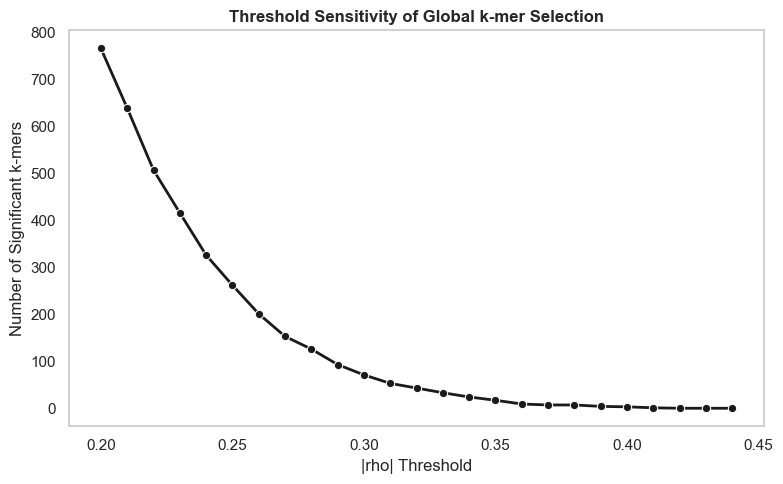

In [41]:
threshs = np.arange(0.2,0.45, 0.01).round(2)
nums = []
for thresh in threshs:
    nums.append(len(filter_significant_kmers(global_sig_kmer, corr_cutoff=thresh)))

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(1, figsize=(8,5))
sns.lineplot(x=threshs, y=nums, ax=ax, marker='o', lw=2, color='k', ls='-')
ax.set_xlabel('|rho| Threshold')
ax.set_ylabel('Number of Significant k-mers')
ax.set_title('Threshold Sensitivity of Global k-mer Selection', fontweight='bold')
plt.grid(False)
plt.tight_layout()

In [42]:
# number of significant kmers by site
site_sig_kmer_df.groupby('site').apply(filter_significant_kmers, alpha=0.05, corr_cutoff=0.25, include_groups=False).apply(len)

site
Mouth    784
Nasal    430
Skin      51
Stool    669
dtype: int64

In [43]:
filter_significant_kmers(global_sig_kmer, corr_cutoff=0.26)

Index(['AAAAGAAT', 'AAACGGAT', 'AAAGCCCG', 'AAAGCGGG', 'AAAGCTCC', 'AAAGCTGG',
       'AAAGGGTA', 'AAATCATA', 'AACCATCT', 'AACTCCGT',
       ...
       'TTCGGAGG', 'TTCGGGCG', 'TTCGGGGG', 'TTCTCTGG', 'TTGAAAAT', 'TTGACGGA',
       'TTGAGAAA', 'TTTCCGGT', 'TTTTGAAC', 'TTTTTCTT'],
      dtype='object', length=201)

In [44]:
sig_kmers = filter_significant_kmers(global_sig_kmer, corr_cutoff=0.25)
len(sig_kmers)

262

In [45]:
pd.Series(sig_kmers).to_csv('../data/sig_kmers.csv', index=False)

__Creating cytokine groups__

- Assigning groups to cytokines

In [46]:
# cytokine groups
cytokine_groups = {
    "Pro_inflammatory": ["IL1A", "IL1B", "IL18", "IL6", "TNFA", "TNFB", 
                         "IFNG", "IFNA", "IFNB","GMCSF", "GCSF", "MCSF", 
                         "IL12P40", "IL12P70", "IL23", "IL27", "LIF",
                         "FASL", "TRAIL", "CD40L"],
    "Regulatory_Anti_inflammatory": ["IL10", "IL1RA", "TGFB"],
    "Th2_Allergy": ["IL4", "IL5", "IL9", "IL13", "IL31"],
    "Th17_Barrier": ["IL17A", "IL17F", "IL21", "IL22"],
    "Chemokines": ["MIP1A", "MIP1B", "RANTES", "MCP1", "MCP3", "EOTAXIN", "MIG", "IP10",
                   "GROA", "ENA78", "SDF1A", "CHEX1", "CHEX2", "CHEX3", "CHEX4", 'IL8'],
    "Growth_Factors": ["TGFA", "HGF", "VEGF", "VEGFD", "PDGFBB", "EGF", "NGF", "BDNF", "SCF", "FGFB"],
    "Adhesion_Metabolic": ["ICAM1", "VCAM1", "LEPTIN", "RESISTIN", "PAI1"],
    "Homeostatic_Survival": ["IL2", "IL7", "IL15"]
}

In [47]:
# Reverse lookup: cytokine -> group
cytokine_to_group = {}
for group, cytokines in cytokine_groups.items():
    for c in cytokines:
        cytokine_to_group[c] = group

# Example: map all cytokines to their group
mapped = {c: cytokine_to_group.get(c, "Unassigned") for c in target}

In [48]:
cytokine_groups_df = pd.Series(mapped.values(), index=mapped.keys(), name='group')
cytokine_groups_df.head()

IL17F        Th17_Barrier
FASL     Pro_inflammatory
TGFA       Growth_Factors
MIP1A          Chemokines
SDF1A          Chemokines
Name: group, dtype: object

### Site-specific kmers

- How does kmers differ across sites? Are there kmers that are present in one and not in the other?

In [49]:
# site specific kmers
site_kmers = calc_stat_test(kmer_data, 'site', sig_kmers, 'kruskal', log=False)

In [50]:
site_kmers.head()

,tstat,pval,effect_size,qval,log2FC_Mouth_Nasal,log2FC_Mouth_Skin,log2FC_Mouth_Stool,log2FC_Nasal_Skin,log2FC_Nasal_Stool,log2FC_Skin_Stool
AAAAGAAT,1084.145256,1.001689e-234,0.546585,2.066476e-234,1.460519,1.792692,3.943511,0.332173,2.482992,2.150819
AAACGGAT,1160.353252,2.931581e-251,0.585113,7.918290e-251,4.049669,1.059920,3.332155,-2.989749,-0.717514,2.272235
AAACTTTA,1091.315697,2.786891e-236,0.550210,5.936305e-236,3.796474,1.653211,0.146971,-2.143263,-3.649502,-1.506239
AAAGCCCG,1213.860676,7.209167e-263,0.612164,2.660284e-262,-1.552482,-0.526072,-3.350967,1.026410,-1.798486,-2.824896
AAAGCGGG,37.800550,3.115074e-08,0.017594,3.115074e-08,-0.296837,-0.532494,-0.361173,-0.235657,-0.064336,0.171321


In [51]:
site_kmers.describe()

,tstat,pval,effect_size,qval,log2FC_Mouth_Nasal,log2FC_Mouth_Skin,log2FC_Mouth_Stool,log2FC_Nasal_Skin,log2FC_Nasal_Stool,log2FC_Skin_Stool
count,262.000000,2.620000e+02,262.000000,2.620000e+02,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,1011.682346,1.188960e-10,0.509951,1.188960e-10,1.199552,0.399704,0.752780,-0.799847,-0.446772,0.353075
std,318.841214,1.924499e-09,0.161194,1.924499e-09,2.931655,1.721681,2.814389,2.020530,2.097309,1.893443
min,37.800550,0.000000e+00,0.017594,0.000000e+00,-5.483736,-4.935770,-5.503850,-6.681735,-6.887661,-4.965955
25%,845.727521,2.671529e-265,0.426050,1.052200e-264,-1.352688,-0.900199,-1.945866,-2.560531,-2.046991,-1.095405
50%,1058.001878,4.985608e-229,0.533368,9.920917e-229,1.633351,1.084757,1.271695,-0.935677,-0.358494,0.446185
75%,1225.380840,7.115064e-183,0.617988,9.464327e-183,3.572247,1.734291,3.206101,0.710522,1.278002,1.755705
max,1622.841170,3.115074e-08,0.818929,3.115074e-08,8.060805,4.891019,7.984606,4.197901,3.648943,6.191995


In [52]:
# perform pairwise comparison (Post-Hoc) to identify sites that are statistically different from each other
site_kmer_ph = posthoc_significant_pairs(kmer_data, 'site', sig_kmers, effect_size=0.3)

In [53]:
# count the number of unique body-site pairs for each kmer
site_kmer_ph = site_kmer_ph.assign(num = site_kmer_ph.significant_pairs.apply(lambda x: len(x.split(','))))

In [54]:
site_kmer_ph

,significant_pairs,num
variable,,
AAAAGAAT,"Mouth-Nasal, Mouth-Skin, Mouth-Stool, Nasal-Sk...",6
AAACGGAT,"Mouth-Nasal, Mouth-Skin, Mouth-Stool, Nasal-Sk...",6
AAACTTTA,"Mouth-Nasal, Mouth-Skin, Nasal-Skin, Nasal-Sto...",5
AAAGCCCG,"Mouth-Nasal, Mouth-Skin, Mouth-Stool, Nasal-Sk...",6
AAAGCTCC,"Mouth-Nasal, Mouth-Skin, Mouth-Stool, Nasal-Sk...",6
...,...,...
TTGACGGA,"Mouth-Nasal, Mouth-Skin, Mouth-Stool, Nasal-Sk...",6
TTGAGAAA,"Mouth-Skin, Mouth-Stool, Nasal-Skin, Nasal-Sto...",5
TTTCCGGT,"Mouth-Nasal, Mouth-Skin, Mouth-Stool, Nasal-Sk...",6


In [55]:
# summarise
site_kmer_ph['num'].value_counts().to_frame().eval(f'prop = count/{len(site_kmer_ph)}')

,count,prop
num,,
6,172,0.744589
5,58,0.251082
4,1,0.004329


In [56]:
site_kmers.shape

(262, 10)

In [57]:
site_kmers.describe()

,tstat,pval,effect_size,qval,log2FC_Mouth_Nasal,log2FC_Mouth_Skin,log2FC_Mouth_Stool,log2FC_Nasal_Skin,log2FC_Nasal_Stool,log2FC_Skin_Stool
count,262.000000,2.620000e+02,262.000000,2.620000e+02,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,1011.682346,1.188960e-10,0.509951,1.188960e-10,1.199552,0.399704,0.752780,-0.799847,-0.446772,0.353075
std,318.841214,1.924499e-09,0.161194,1.924499e-09,2.931655,1.721681,2.814389,2.020530,2.097309,1.893443
min,37.800550,0.000000e+00,0.017594,0.000000e+00,-5.483736,-4.935770,-5.503850,-6.681735,-6.887661,-4.965955
25%,845.727521,2.671529e-265,0.426050,1.052200e-264,-1.352688,-0.900199,-1.945866,-2.560531,-2.046991,-1.095405
50%,1058.001878,4.985608e-229,0.533368,9.920917e-229,1.633351,1.084757,1.271695,-0.935677,-0.358494,0.446185
75%,1225.380840,7.115064e-183,0.617988,9.464327e-183,3.572247,1.734291,3.206101,0.710522,1.278002,1.755705
max,1622.841170,3.115074e-08,0.818929,3.115074e-08,8.060805,4.891019,7.984606,4.197901,3.648943,6.191995


__Clustering log fold changes for each site pairs to find any clusters__

In [58]:
xpca = PCA(2).fit_transform(st.zscore(site_kmers.filter(regex='log2FC').values))

100%|██████████| 12/12 [00:14<00:00,  1.22s/it]


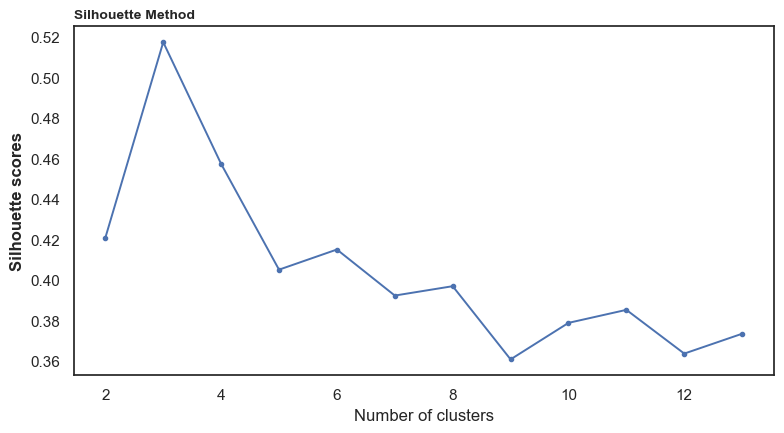

In [59]:
sns.set_theme(style='white')
get_optimal_clusters(xpca, scale=True, scorer='silhouette')

In [60]:
clusters = cluster_data(xpca, 3, scale=True)[0]

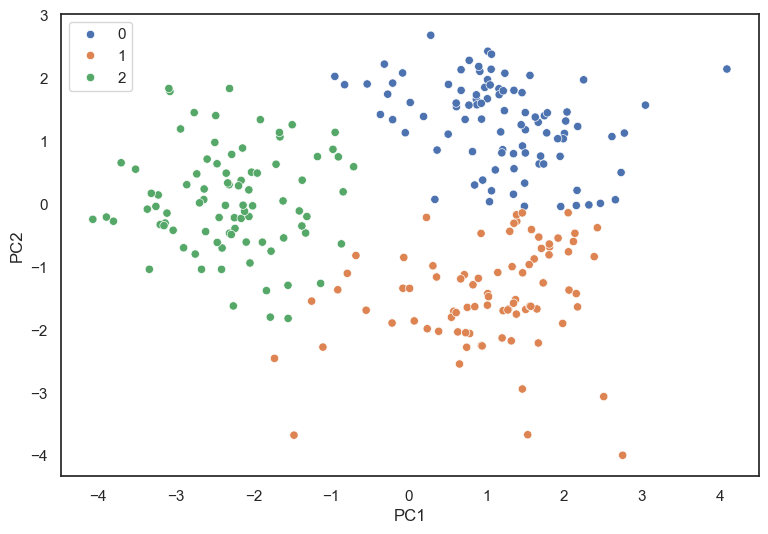

In [61]:
plt.figure(figsize=(9,6))
sns.scatterplot(x=xpca[:, 0], y=xpca[:, 1], hue=map(str, clusters), hue_order=['0','1','2'])
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.grid(False)

In [62]:
site_kmers.assign(gp = clusters).query('qval < 0.05').groupby('gp').size()

gp
0    92
1    84
2    86
dtype: int64

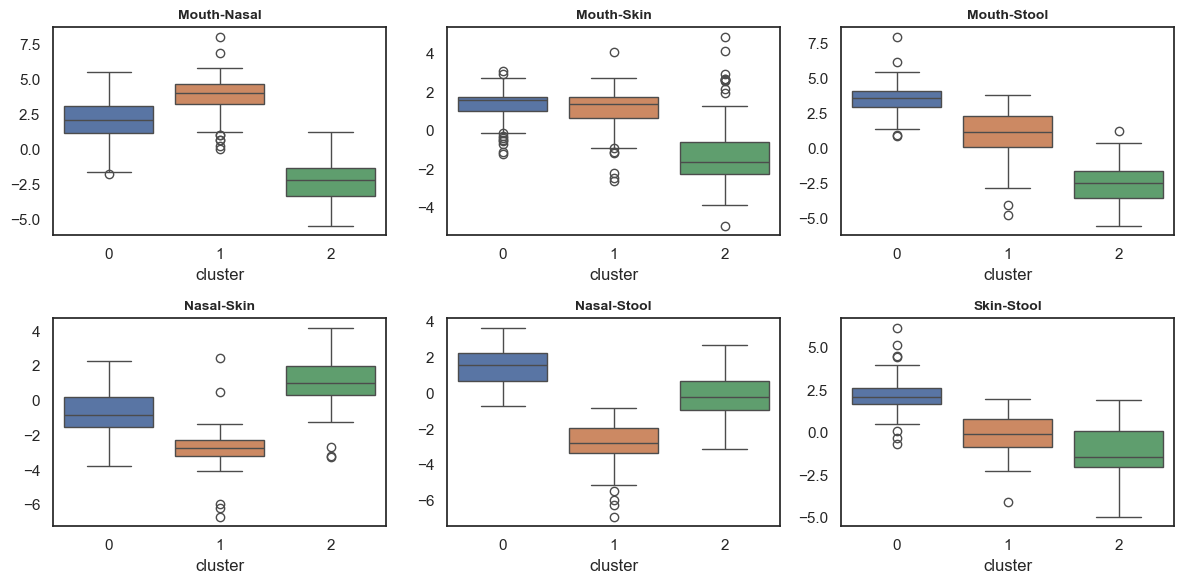

In [63]:
fig = plt.figure(figsize=(12,6))
for i, col in enumerate(site_kmers.filter(like='log2FC').columns):
    plt.subplot(2,3, i+1)
    sns.boxplot(data=site_kmers, x=clusters, y=col, hue=map(str, clusters), legend=False)
    plt.title(col.replace('log2FC_', '').replace('_', '-'), fontsize=10, fontweight='bold')
    plt.ylabel('')
    plt.xlabel('cluster')
fig.tight_layout()

In [64]:
# number of kmers with absolute fold change at least 2
(site_kmers.query('qval < 0.05 & effect_size > 0.3').filter(like='log2').apply(lambda x: np.where(abs(x) < 2, 0, x)) != 0).mean()

log2FC_Mouth_Nasal    0.701299
log2FC_Mouth_Skin     0.203463
log2FC_Mouth_Stool    0.709957
log2FC_Nasal_Skin     0.476190
log2FC_Nasal_Stool    0.411255
log2FC_Skin_Stool     0.329004
dtype: float64

- Visualise log fold changes of site kmers

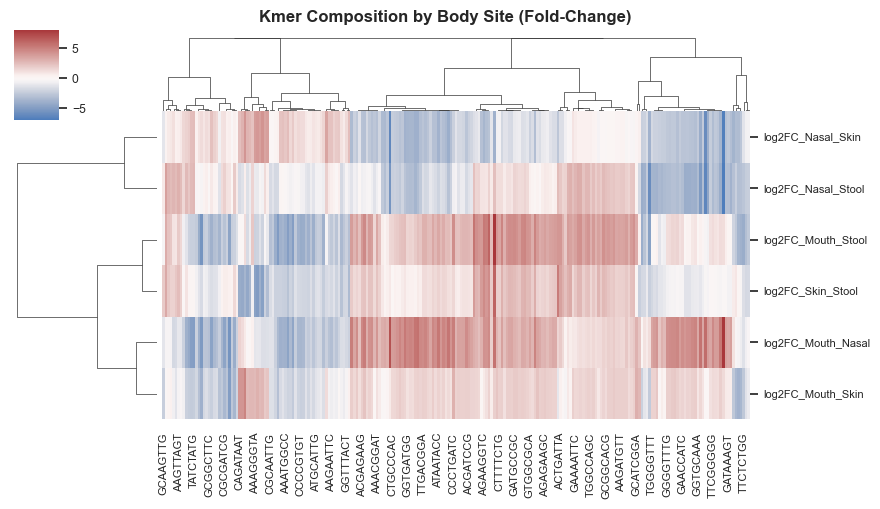

In [65]:
# filter by selecting thise with effect size >= 0.3
sns.set_theme(font_scale=.8)
g = sns.clustermap(site_kmers.query('qval < 0.05 & effect_size >= 0.3').filter(like='log2FC').T, 
                   metric='correlation', method='complete', z_score=None, cmap='vlag', center=0, figsize=(9,5))
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8)
plt.suptitle('Kmer Composition by Body Site (Fold-Change)', fontsize=12, fontweight='bold', y=1.02)
plt.savefig('imgs/kmer_clustermap_by_body_site.png', dpi=300, bbox_inches='tight');

In [66]:
def group_mean_matrix(df, features, term, agg_func='mean', normalise=True, log_scale=False):
    """
    Calculates Relative mean deviation of group to overall sample
    
    """
    mean_vals = df[features].mean() if not log_scale else (np.expm1(df[features])).mean()
    if ':' in term:
        cols = term.split(':')
        key = df[cols].apply(lambda x: '|'.join(x), axis=1).rename('group')
        G = pd.concat([key, df[features]], axis=1) if not log_scale else pd.concat([key, np.expm1(df[features])], axis=1)
        M = G.groupby('group')[features].agg(agg_func)
    else:
        key = df[term]
        G = pd.concat([key, df[features]], axis=1) if not log_scale else pd.concat([key, np.expm1(df[features])], axis=1)
        M = G.groupby(term)[features].agg(agg_func)
    
    return (M-mean_vals) /mean_vals if normalise else M - mean_vals

In [67]:
def compare_group_mean_matrix(res, ref_class=None):
    """
    Compares group pairs of a relative group mean values to overall mean

    :param res: Pandas DataFrame with class as index and features as columns
    :param ref_class: str|None. Reference class
    """
    res_matrix = {}
    if ref_class is None:
        combs = list(combinations(res.index, 2))
    else:
        combs = [(ref_class, i) for i in res.index.difference(set([ref_class]))]
    combs = list(map(list, combs))

    for comb in combs:
        res_matrix[f'|'.join(comb)] = (res.loc[comb[1]] - res.loc[comb[0]]).values.tolist()
    
    return pd.DataFrame.from_dict(res_matrix, orient='index', columns=res.columns)


## __Dysregulated kmers|cytokines__

Here, we will identify dysregulated kmers and cytokines at various group combinations

#### Demographics

**Age and Gender**

- Age

In [68]:
cytokine_df.age_gp.value_counts()

age_gp
Senior         292
Middle-aged    279
Young           99
Name: count, dtype: int64

In [69]:
age_cyt = calc_stat_test(cytokine_df, groups='age_gp', features=target, test='kruskal', log=True)

In [70]:
age_kmer = pd.concat([calc_stat_test(kmer_data.query(f'site =="{site}"'), groups='age_gp', 
                                     features=sig_kmers, test='anova', log=False).assign(key=site) for site in sites])

In [71]:
# significant kmers by age
age_kmer_sig = age_kmer.query('qval < 0.05 & effect_size >= 0.1').index.unique().tolist()
len(age_kmer_sig)

50

__how many with at least 1.5 fold change ratio?__

In [72]:
# kmers with fold change at least 2
(
    age_kmer
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x == 0, np.nan, x))
    .reset_index(level=[0]).dropna().index.unique()
)

Index(['CACTCCGG', 'ACGAGAAG', 'ATGCATAG', 'CGCACTTT', 'GCACTTTA', 'GCGTATTA',
       'TCTCTGAT', 'TTTTGAAC', 'AGTATAAC', 'CCATTAAA', 'GACCTAGC', 'GATGGGAT',
       'GTAAGCAT', 'TACACTCT'],
      dtype='object')

In [73]:
# kmers with fold change at least 2
(
    age_kmer
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x == 0, np.nan, x))
    .reset_index(level=[0]).dropna().index.nunique()
)

14

In [74]:
# number of significant kmers in each site for age
(
    age_kmer
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna().reset_index()
    .groupby('key')['level_1'].nunique()
)

key
Mouth    1
Nasal    7
Stool    6
Name: level_1, dtype: int64

In [75]:
# significant cytokines by age
age_cyt_sig = age_cyt.query('qval < 0.05 & effect_size >= 0.06').index.tolist()
len(age_cyt_sig)

30

In [76]:
# how many with at leat 1.5 fold change ratio?
age_cyt.query('qval < 0.05').filter(like='log').apply(lambda x: abs(x) >= 1.5).sum(1).sum()

np.int64(0)

In [77]:
age_kmer_df = (
    age_kmer
    .filter(regex='log|key')
    .reset_index(names='kmer')
    .melt(id_vars=['kmer', 'key'])
    .replace('log2FC_', '', regex=True)
    .pivot(index='kmer', columns=['key', 'variable'], values='value')
)

age_kmer_df.columns = [f'{i}_{j}' for i, j in age_kmer_df.columns]

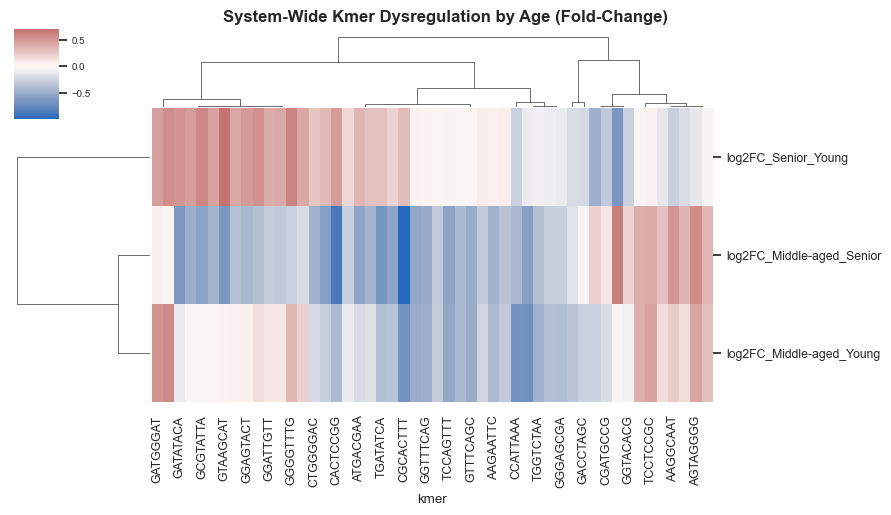

In [78]:
sns.set_theme(font_scale=.8)
sns.clustermap(age_kmer.loc[age_kmer_sig].filter(regex='log2').reset_index(names='kmer').groupby(['kmer']).mean().T, metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5))
plt.yticks(fontsize=7)
plt.xticks(fontsize=7)
plt.suptitle('System-Wide Kmer Dysregulation by Age (Fold-Change)', fontsize=12, fontweight='bold', y=1.02);

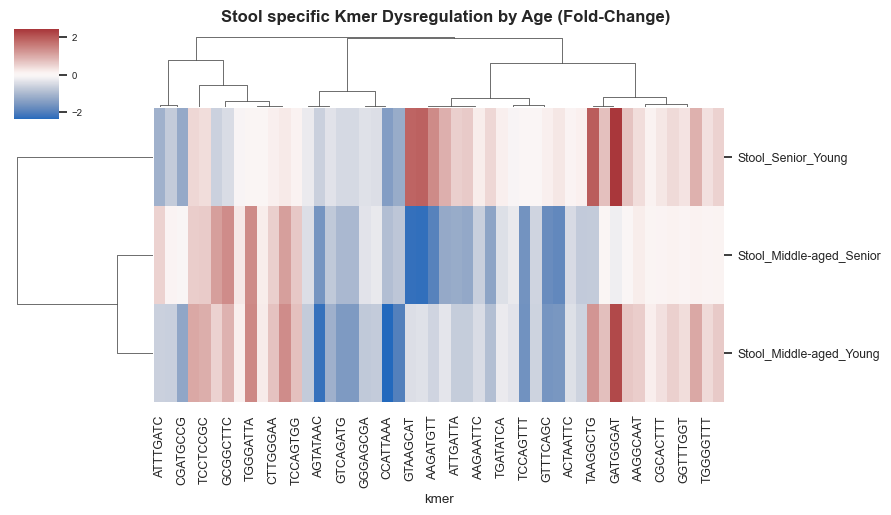

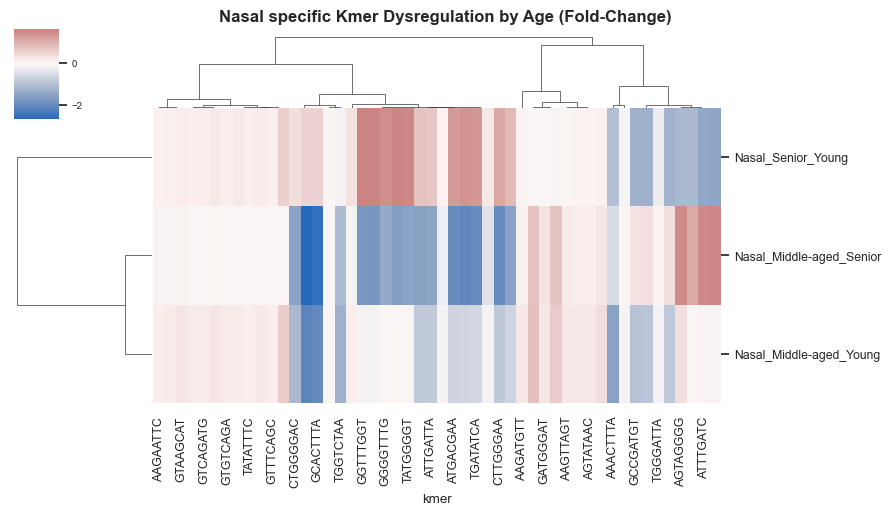

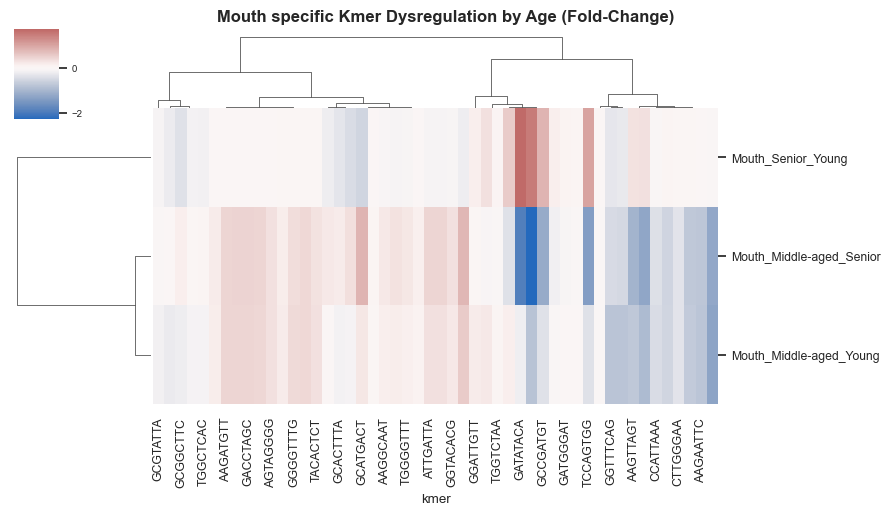

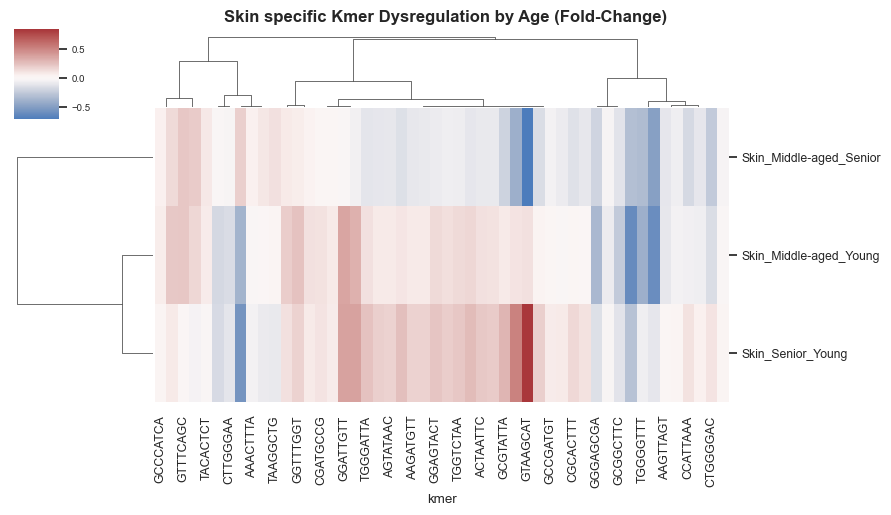

In [79]:
sns.set_theme(font_scale=.8)
for i in sites:
    sns.clustermap(age_kmer_df.loc[age_kmer_sig].filter(like=i).T, metric='correlation', 
                method='complete', cmap='vlag', center=0,figsize=(9,5))
    plt.yticks(fontsize=7)
    plt.xticks(fontsize=7)
    plt.suptitle(f'{i} specific Kmer Dysregulation by Age (Fold-Change)', fontsize=12, fontweight='bold', y=1.02)
    plt.savefig(f'imgs/{i}_dysregulation_age.png', dpi=250);

In [80]:
# Create a color palette
palette = sns.color_palette("Set2", len(set(cytokine_groups_df.loc[age_cyt_sig])))
lut = dict(zip(set(cytokine_groups_df.loc[age_cyt_sig]), palette))

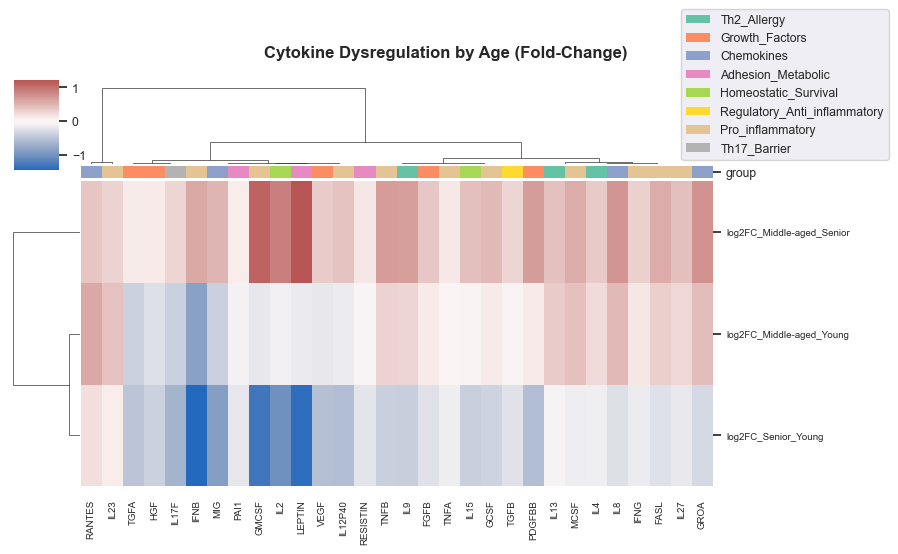

In [81]:
sns.set_theme(font_scale=.8)
g = sns.clustermap(age_cyt.loc[age_cyt_sig].filter(like='log2').T, metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5), 
               dendrogram_ratio = (.1, .2),
               col_colors=pd.Series(cytokine_groups_df.loc[age_cyt_sig]).map(lut))
for label in lut:
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc=(0.95,0.05), ncol=1)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
plt.suptitle('Cytokine Dysregulation by Age (Fold-Change)', fontsize=12, fontweight='bold', y=1.05);

In [82]:
group_mean_matrix(cytokine_df, age_cyt_sig, 'age_gp')

,IL17F,FASL,TGFA,IL27,IL2,IL4,IL8,IFNB,IL13,RANTES,...,IL12P40,IL15,MCSF,MIG,RESISTIN,FGFB,PDGFBB,VEGF,LEPTIN,PAI1
age_gp,,,,,,,,,,,,,,,,,,,,,
Middle-aged,-0.051926,-0.201793,-0.001132,-0.157832,-0.275031,-0.130697,-0.261226,-0.139351,-0.161148,-0.170497,...,-0.109502,-0.138447,-0.208572,-0.127594,-0.041252,-0.127623,-0.214907,-0.091558,-0.359950,-0.022658
Senior,0.142908,0.191828,0.081565,0.147521,0.375473,0.117777,0.237216,0.309914,0.129653,0.079506,...,0.172954,0.171799,0.176101,0.234886,0.065194,0.134754,0.255082,0.155323,0.489730,0.051000
Young,-0.275170,0.002894,-0.237383,0.009687,-0.332368,0.020943,0.036517,-0.521375,0.071734,0.245990,...,-0.201530,-0.116551,0.068384,-0.333212,-0.076034,-0.037793,-0.146716,-0.200098,-0.430051,-0.086568


In [83]:
age_cyt.query('qval < 0.05').filter(regex='log').apply(lambda x: abs(x) >= 1).sum(1).apply(lambda x: np.where(x == 0, np.nan, x)).dropna()

IL2       1.0
IFNB      1.0
GMCSF     2.0
LEPTIN    2.0
dtype: float64

---

- **Gender**

In [84]:
cytokine_df.Gender.value_counts()

Gender
M    389
F    281
Name: count, dtype: int64

In [85]:
sex_cyt = calc_stat_test(cytokine_df, groups='Gender', features=target, test='ttest', log=True)

In [86]:
sex_kmer = pd.concat([calc_stat_test(kmer_data.query(f'site =="{site}"'), groups='Gender', 
                                     features=sig_kmers, test='ttest', log=False).assign(key=site) for site in sites])

In [87]:
# significant kmers by gender
sex_kmer_sig = sex_kmer.query('qval < 0.05 & effect_size >= 0.5').index.unique().tolist()
len(sex_kmer_sig)

54

In [ ]:
# kmers with fold change at least 2
(
    sex_kmer
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key').apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x == 0, np.nan, x))
    .reset_index(level=[0]).dropna().index.unique()
)

Index(['AACCATCT', 'ACCATCTT', 'CTTGGGAA', 'GAACCATC', 'GGAACCAT'], dtype='object')

In [89]:
# dysregulated kmers by body site
(
    sex_kmer.query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna()
    .reset_index()
    .groupby('key')['level_1'].unique()
)

key
Nasal    [AACCATCT, ACCATCTT, CTTGGGAA, GAACCATC, GGAAC...
Name: level_1, dtype: object

In [90]:
# dysregulated kmers by body site
(
    sex_kmer.query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna()
    .reset_index()
    .groupby('key')['level_1'].nunique()
)

key
Nasal    5
Name: level_1, dtype: int64

In [91]:
# significant cytokines by gender
sex_cyt_sig = sex_cyt.query('qval < 0.05 & effect_size >= 0.06').index.tolist()
len(sex_cyt_sig)

24

In [92]:
# dysrergulated cytokine
sex_cyt.query('qval < 0.05').filter(regex='log').apply(lambda x: abs(x) >= 1.5).sum(1).apply(lambda x: np.where(x == 0, np.nan, x)).dropna()

LEPTIN    1.0
dtype: float64

In [93]:
# relative group mean deviation from sample mean
group_mean_matrix(cytokine_df, ['LEPTIN'], 'Gender')

,LEPTIN
Gender,
F,0.700769
M,-0.506211


In [94]:
# by how much difference (compare mean deviation of both groups)
compare_group_mean_matrix(group_mean_matrix(cytokine_df, ['LEPTIN'], 'Gender'), 'M')

,LEPTIN
M|F,1.206981


In [95]:
sex_kmer_df = sex_kmer.filter(regex='log2|key').reset_index(names='kmer').melt(id_vars=['kmer', 'key']).replace('log2FC_', '', regex=True).pivot(
    index='kmer', columns=['key', 'variable'], values='value')

sex_kmer_df.columns = [f'{i}|{j}' for i, j in sex_kmer_df.columns]

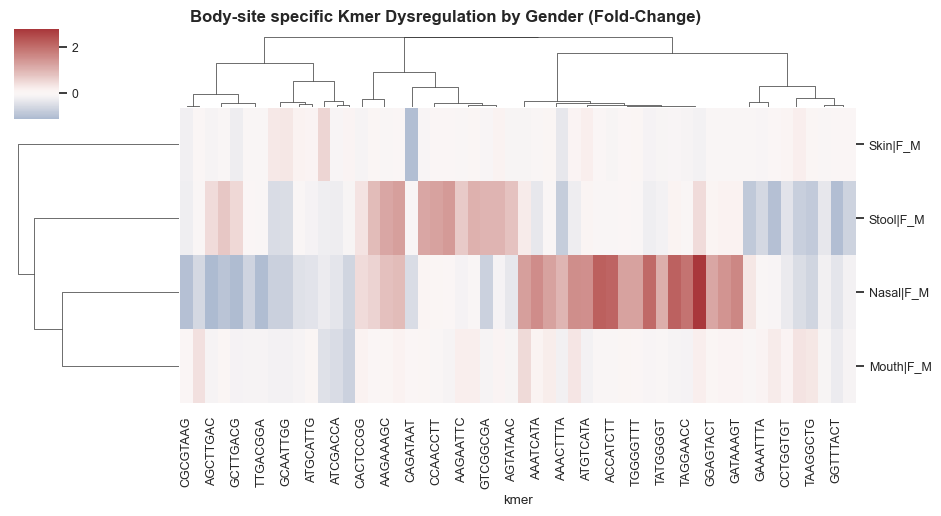

In [96]:
sns.set_theme(font_scale=.8)
g = sns.clustermap(sex_kmer_df.loc[sex_kmer_sig].T, metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5))
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=9)
plt.suptitle('Body-site specific Kmer Dysregulation by Gender (Fold-Change)', fontsize=12, fontweight='bold', y=1.02);

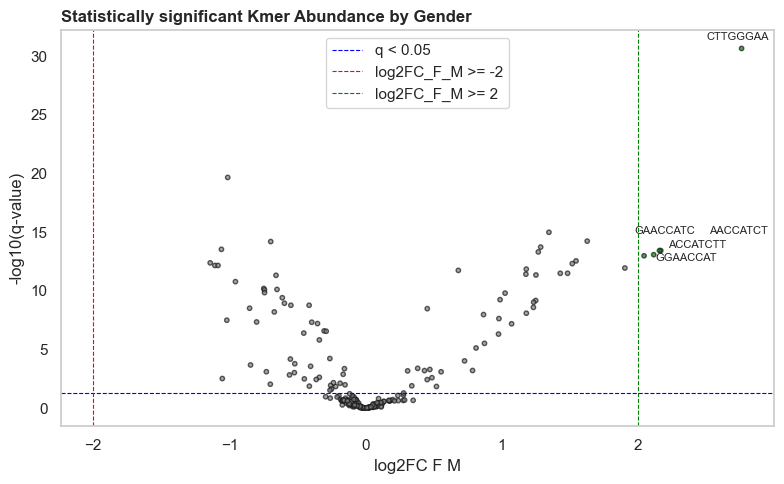

In [97]:
sns.set_theme(style='whitegrid', font_scale=1)
volcano_plot(sex_kmer.loc[sex_kmer_sig], 'log2FC_F_M', corr_thresh=[-2,2], N=10, figsize=(8,5), 
title='Statistically significant Kmer Abundance by Gender')
plt.savefig('imgs/kmer_dysregulation_by_gender.png')

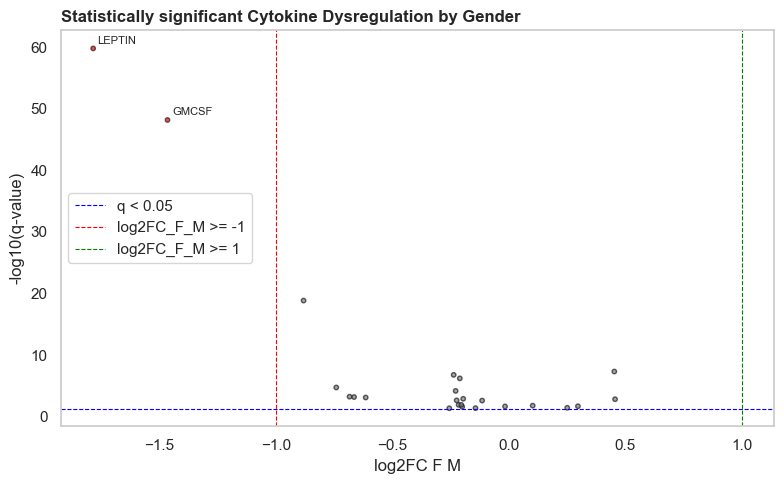

In [98]:
sns.set_theme(style='whitegrid', font_scale=1)
volcano_plot(sex_cyt.loc[sex_cyt_sig], 'log2FC_F_M', corr_thresh=[-1, 1], N=len(sex_cyt_sig), figsize=(8,5), 
title='Statistically significant Cytokine Dysregulation by Gender')

In [99]:
cytokine_df.groupby('Gender').LEPTIN.mean()

Gender
F    5719.985419
M    1660.698116
Name: LEPTIN, dtype: float64

In [100]:
cytokine_df.groupby(['Gender', 'age_gp', 'BMI_group']).LEPTIN.size().unstack(0).fillna(0).astype(int)

Gender                   F    M
age_gp      BMI_group          
Middle-aged normal       8  113
            obese       35    0
            overweight  43   80
Senior      normal       0   31
            obese       92   66
            overweight  50   53
Young       normal      23   34
            obese        3    0
            overweight  27   12

<Axes: xlabel='age_gp'>

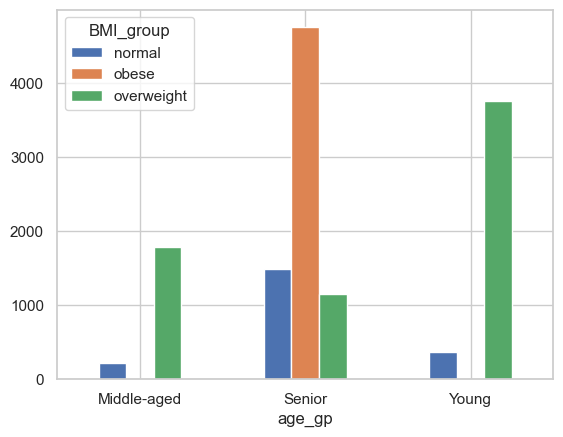

In [101]:
cytokine_df.query('Gender == "M"').groupby(['age_gp', 'BMI_group']).LEPTIN.mean().unstack(1).plot.bar(rot=0)

In [102]:
cytokine_df.query('Gender == "F"').groupby(['age_gp', 'BMI_group']).LEPTIN.mean().unstack(1)

BMI_group,normal,obese,overweight
age_gp,,,
Middle-aged,2471.527049,7303.958494,3656.745773
Senior,NaN,7993.783869,6139.284076
Young,1547.480244,5514.552587,2968.038808


<Axes: xlabel='age_gp'>

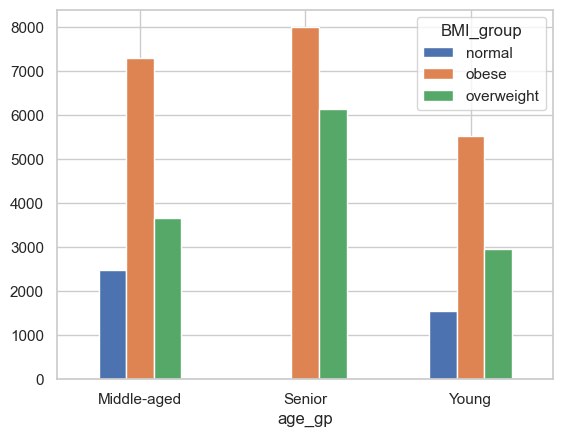

In [103]:
cytokine_df.query('Gender == "F"').groupby(['age_gp', 'BMI_group']).LEPTIN.mean().unstack(1).plot.bar(rot=0)

In [104]:
len(sex_cyt_sig)

24

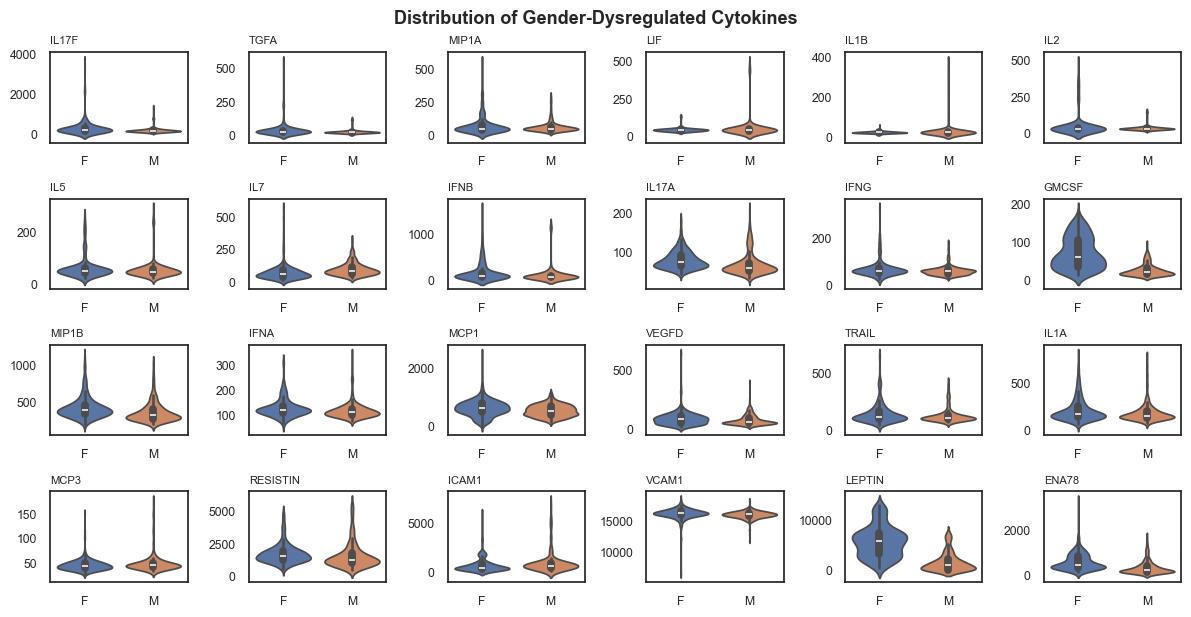

In [105]:
sns.set_theme(style='white', font_scale=0.8)
plt.figure(figsize=(12,6))
for i, cyt in enumerate(sex_cyt_sig):
    plt.subplot(4,6, i+1)
    sns.violinplot(data=cytokine_df, x='Gender', y=cyt, hue='Gender')
    plt.grid(False)
    plt.xlabel('')
    plt.ylabel('')
    plt.title(cyt, fontsize=8, loc='left', fontweight=22)
plt.tight_layout()
plt.suptitle('Distribution of Gender-Dysregulated Cytokines', fontsize=13, fontweight='bold', y=1.02);

### **Metabolic related**

**BMI and FPG**

- BMI

In [106]:
bmi_cyt = calc_stat_test(cytokine_df, 'BMI_group', target, 'kruskal', log=True)

bmi_kmer_site = pd.concat(
    [calc_stat_test(kmer_data.query(f'site == "{site}"'), 'BMI_group', sig_kmers, 'anova', log=False).assign(key=site) for site in kmer_data.site.unique()]
    )

In [107]:
bmi_kmer_sig = bmi_kmer_site.query('qval < 0.05 & effect_size >= 0.15').index.unique().tolist()
len(bmi_kmer_sig)

36

In [108]:
bmi_cyt_sig = bmi_cyt.query('qval < 0.05 & effect_size >= 0.06').index.unique().tolist()

len(bmi_cyt_sig)

28

In [109]:
# kmers with fold change at least 2
bmi_kmer_sig_2fc = (
    bmi_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key').apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x == 0, np.nan, x))
    .reset_index(level=[0])
    .dropna().index.unique()
    )
bmi_kmer_sig_2fc

Index(['CACTCCGG', 'CGGAGATT', 'AAACGGAT', 'AACCATCT', 'ACCATCTT', 'ACGGATGC',
       'ACTAATTC', 'ACTGATTA', 'AGGCAGTG', 'ATCACTGC', 'ATGACGAA', 'ATTCGGAA',
       'ATTGATTA', 'CCCCATAG', 'CGCATGAC', 'CGGATGCT', 'CTTGGGAA', 'GAACCATC',
       'GACAACAT', 'GACTGATT', 'GATGCTAA', 'GCATGACT', 'GCGTATTA', 'GGAACCAT',
       'GGTGCAAA', 'TACCCCAT', 'TAGGAACC', 'TGACTAAT', 'TGAGGAAC', 'TGATATCA',
       'TGATTGAT', 'TTCGGAGG', 'AAAGGGTA', 'AAGGGTAC', 'AAGTTAGA', 'CAGATAAT',
       'CTAGAAAA', 'GGGTACGT', 'TTGAGAAA', 'CCAACCTT', 'CCATTAAA', 'CTTGGCCA',
       'GGACGATC', 'GTATTTTC', 'TAAGGCTG', 'TAGTCAAC', 'TGGCCAGC'],
      dtype='object')

In [ ]:
(
    bmi_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key').apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x == 0, np.nan, x))
    .reset_index(level=[0]).dropna().index.unique().shape
)

(47,)

In [ ]:
(
    bmi_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key').apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna().reset_index()
    .groupby('key')['level_1'].unique())

key
Mouth                                 [CACTCCGG, CGGAGATT]
Nasal    [AAACGGAT, AACCATCT, ACCATCTT, ACGGATGC, ACTAA...
Skin     [AAAGGGTA, AAGGGTAC, AAGTTAGA, CAGATAAT, CTAGA...
Stool    [CCAACCTT, CCATTAAA, CTTGGCCA, GGACGATC, GTATT...
Name: level_1, dtype: object

In [ ]:
(
    bmi_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key').apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna().reset_index()
    .groupby('key')['level_1'].nunique())

key
Mouth     2
Nasal    30
Skin      7
Stool     8
Name: level_1, dtype: int64

In [ ]:
# kmers with fold change at least 1.5
(
    bmi_cyt
    .query('qval < 0.05')
    .filter(regex='log')
    .apply(lambda x: abs(x) >= 1.5).sum(1)
    .apply(lambda x: np.where(x == 0, np.nan, x)).dropna().index.unique()
)

Index(['IFNB', 'GMCSF', 'LEPTIN'], dtype='object')

In [114]:
bmi_cyt_ph = posthoc_significant_pairs(cytokine_df, 'BMI_group', bmi_cyt_sig, effect_size=0.08)
bmi_cyt_ph

,significant_pairs
variable,
TGFA,"normal-obese, normal-overweight, obese-overweight"
IL27,"normal-obese, normal-overweight"
LIF,"normal-obese, normal-overweight, obese-overweight"
IFNB,"normal-obese, normal-overweight"
IL17A,"normal-obese, normal-overweight"
IL31,"normal-obese, normal-overweight, obese-overweight"
IL1RA,"normal-obese, normal-overweight"
GMCSF,"normal-obese, normal-overweight, obese-overweight"
TNFA,"normal-obese, normal-overweight"


In [115]:
group_mean_matrix(cytokine_df, ['IFNB', 'GMCSF', 'LEPTIN'], 'BMI_group')

,IFNB,GMCSF,LEPTIN
BMI_group,,,
normal,-0.504129,-0.609235,-0.802603
obese,-0.333386,0.855323,1.004248
overweight,0.644176,-0.152126,-0.109768


In [116]:
100*compare_group_mean_matrix(group_mean_matrix(cytokine_df, ['IFNB', 'GMCSF', 'LEPTIN'], 'BMI_group'))

,IFNB,GMCSF,LEPTIN
normal|obese,17.074222,146.455816,180.685151
normal|overweight,114.830449,45.710889,69.283515
obese|overweight,97.756227,-100.744927,-111.401636


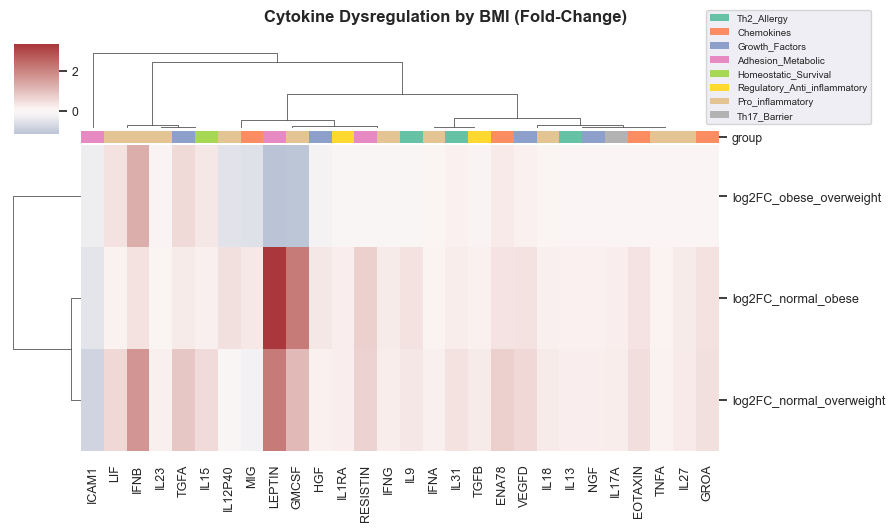

In [117]:
sns.set_theme(font_scale=.8)
# Create a color palette
palette = sns.color_palette("Set2", len(set(cytokine_groups_df.loc[bmi_cyt_sig])))
lut = dict(zip(set(cytokine_groups_df.loc[bmi_cyt_sig]), palette))

g = sns.clustermap(bmi_cyt.loc[bmi_cyt_sig].filter(like='log2').T, metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5), 
               dendrogram_ratio = (.1, .2),
               col_colors=pd.Series(cytokine_groups_df.loc[bmi_cyt_sig]).map(lut))
for label in lut:
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc=(0.98,0.05), ncol=1, fontsize=7)

g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=9)
plt.suptitle('Cytokine Dysregulation by BMI (Fold-Change)', fontsize=12, fontweight='bold', y=1.05)
plt.savefig('imgs/cytokine_dysregulation_bmi.png', bbox_inches='tight', dpi=300);

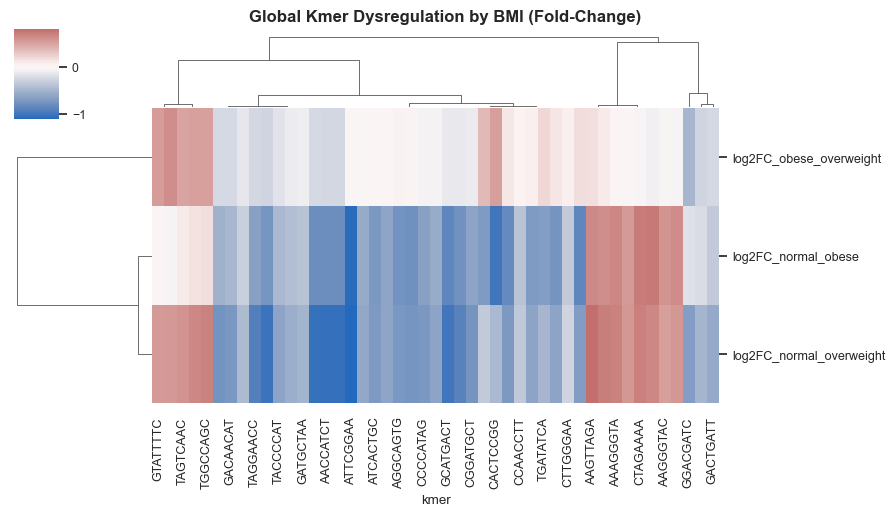

In [118]:
sns.set_theme(font_scale=.8)
g = sns.clustermap(bmi_kmer_site.loc[bmi_kmer_sig_2fc].filter(regex='log2').reset_index(names='kmer').groupby(['kmer']).mean().T, metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5))
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=9)
plt.suptitle('Global Kmer Dysregulation by BMI (Fold-Change)', fontsize=12, fontweight='bold', y=1.02);

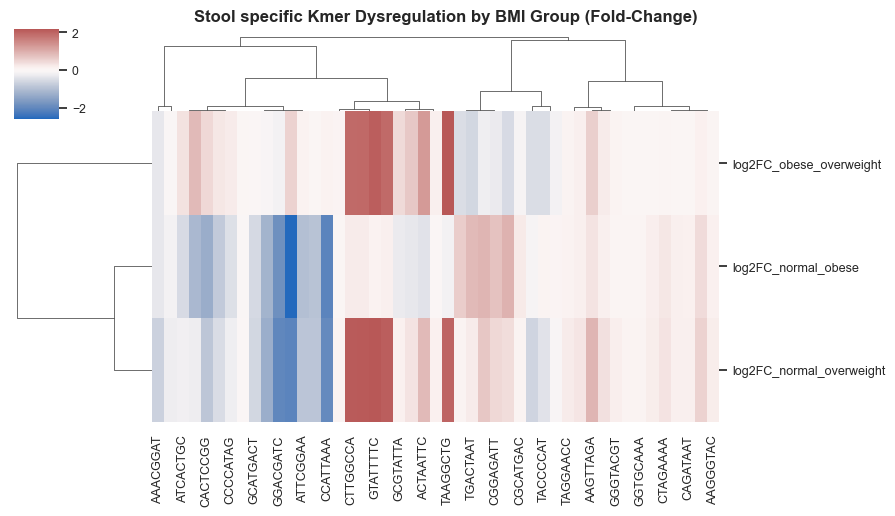

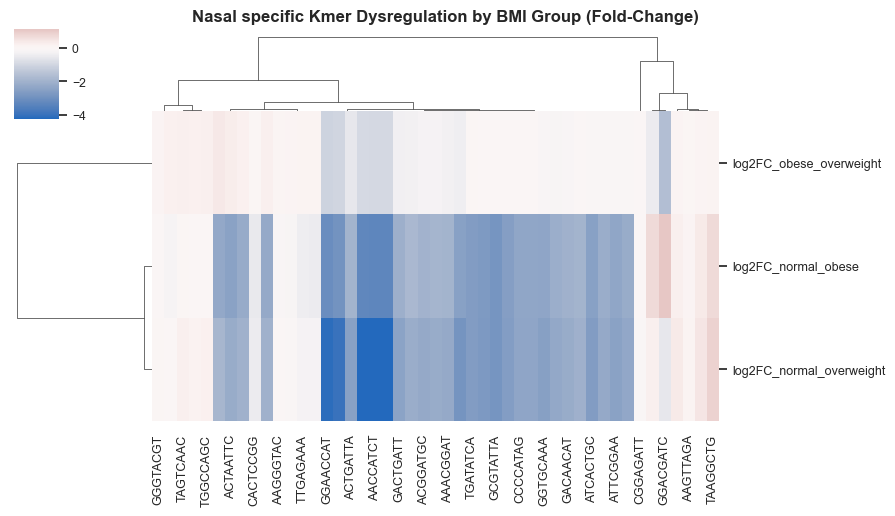

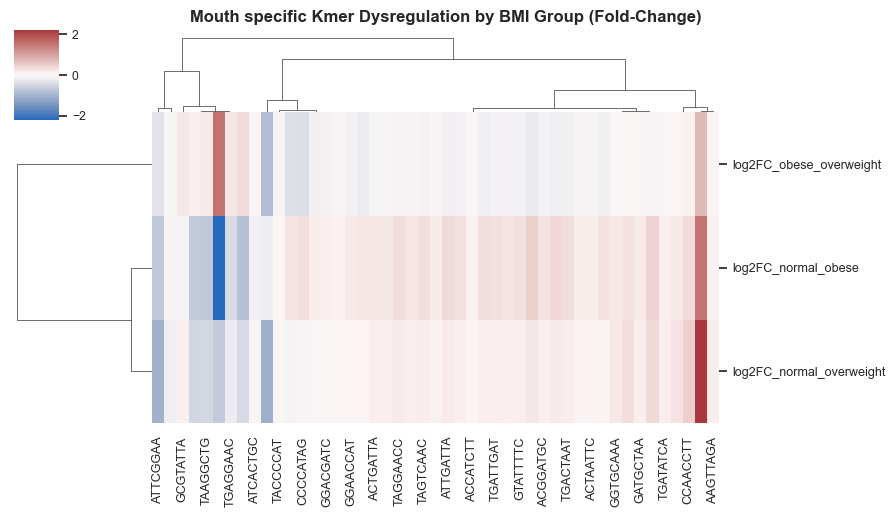

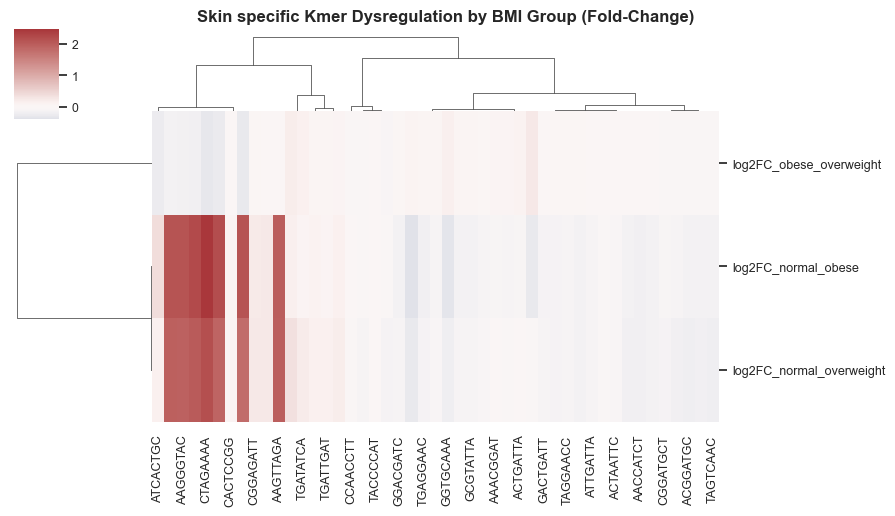

In [119]:
sns.set_theme(font_scale=.8)
for i in sites:
    g = sns.clustermap(bmi_kmer_site.loc[bmi_kmer_sig_2fc].query(f'key=="{i}"').filter(like='log2').T, metric='correlation', 
                method='complete', cmap='vlag', center=0,figsize=(9,5))
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=9)
    plt.suptitle(f'{i} specific Kmer Dysregulation by BMI Group (Fold-Change)', fontsize=12, fontweight='bold', y=1.02)
    plt.savefig(f'imgs/{i}_Dysregulation_bmi.png', dpi=300, bbox_inches='tight');

---

__FPG__

In [120]:
fpg_cyt = calc_stat_test(cytokine_df, 'FPG_class', target, 'kruskal', log=True)

fpg_kmer_site = pd.concat(
    [calc_stat_test(kmer_data.query(f'site == "{site}"'), 'FPG_class', sig_kmers, 'anova', log=False).assign(key=site) for site in kmer_data.site.unique()]
    )

In [121]:
fpg_kmer_sig = fpg_kmer_site.query('qval < 0.05 & effect_size >= 0.2').index.unique().tolist()
len(fpg_kmer_sig)

63

In [122]:
fpg_cyt_sig = fpg_cyt.query('qval < 0.05 & effect_size >= 0.06').index.unique().tolist()

len(fpg_cyt_sig)

44

In [123]:
# kmers with fold change at least 2
fpg_kmer_sig_2fc = (
    fpg_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key').apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x == 0, np.nan, x))
    .reset_index(level=[0])
    .dropna().index.unique()
    )
fpg_kmer_sig_2fc

Index(['AACCATGC', 'AAGCGCTT', 'AATTAGCT', 'AGCTTGTA', 'ATGCATTG', 'ATTCGGAA',
       'CAACCATG', 'CAAGGCTT', 'CACTCCGG', 'CCCCGTGT',
       ...
       'TGCTTTAG', 'TGGCCAGC', 'TGGTAAAG', 'TGGTCTAA', 'TGTAAAGC', 'TGTCGGAT',
       'TGTCGGCG', 'TTAAATCC', 'TTGAAAAT', 'TTTCCGGT'],
      dtype='object', length=139)

In [124]:
len(fpg_kmer_sig_2fc)

139

In [125]:
(
    fpg_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna()
    .reset_index().groupby('key')['level_1'].unique()
)

key
Mouth    [AACCATGC, AAGCGCTT, AATTAGCT, AGCTTGTA, ATGCA...
Nasal    [AAACGGAT, AAAGCTGG, AACCATCT, AATGGCTT, ACCAT...
Skin     [AAAGGGTA, AAATGGCC, AAGGGTAC, AAGTTAGA, ATTCT...
Stool    [AAGATGTT, AATATCAT, AATTATTA, AATTCCGA, ACGAG...
Name: level_1, dtype: object

In [126]:
(
    fpg_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna()
    .reset_index().groupby('key')['level_1'].nunique()
)

key
Mouth    35
Nasal    46
Skin     11
Stool    62
Name: level_1, dtype: int64

In [127]:
fpg_site_kmer_list = (
    fpg_kmer_site
    .query('qval < 0.05')
    .filter(regex='log|key')
    .groupby('key')
    .apply(lambda x: abs(x) >= 2).sum(1)
    .apply(lambda x: np.where(x ==0, np.nan, x)).dropna()
    .reset_index().groupby('key')['level_1'].unique().apply(lambda x: set(x.tolist())).to_dict()
)

In [128]:
# how many shared by each site?
[(i, count_kmers_for_combo(fpg_site_kmer_list, i)[1]) for i in list(combinations(sites, 2))]

[(('Stool', 'Nasal'),
  {'ACGAGAAG', 'ACGGATGC', 'ATGGCTTA', 'ATTGATTA', 'GCTTTGCT'}),
 (('Stool', 'Mouth'),
  {'GATAGTCT', 'GATTATTA', 'GGTTTCAG', 'GTTTCAGC', 'TTCAGCTT'}),
 (('Stool', 'Skin'), {'ATTCTTCC', 'GTAAGCAT', 'GTCAGATG'}),
 (('Nasal', 'Mouth'), {'ATTCGGAA', 'CGCACTTT'}),
 (('Nasal', 'Skin'), set()),
 (('Mouth', 'Skin'), set())]

In [129]:
# kmers with fold change at least 1 (2 times)
fpg_cyt_sig_fc = fpg_cyt.query('qval < 0.05').filter(regex='log').apply(lambda x: abs(x) >= 1.5).sum(1).apply(lambda x: np.where(x == 0, np.nan, x)).dropna().index.unique()
fpg_cyt_sig_fc

Index(['GMCSF', 'IL22', 'LEPTIN', 'ENA78'], dtype='object')

In [130]:
group_mean_matrix(cytokine_df, fpg_cyt_sig_fc, 'FPG_class')

,GMCSF,IL22,LEPTIN,ENA78
FPG_class,,,,
Diabetes,-0.723703,-0.731812,-0.987804,-0.687765
Normal,0.196005,0.005522,0.236367,0.044377
Prediabetes,-0.262328,0.431693,-0.245325,0.263960


In [131]:
compare_group_mean_matrix(group_mean_matrix(cytokine_df, fpg_cyt_sig_fc, 'FPG_class'), 'Normal')

,GMCSF,IL22,LEPTIN,ENA78
Normal|Diabetes,-0.919709,-0.737334,-1.224171,-0.732142
Normal|Prediabetes,-0.458333,0.426171,-0.481692,0.219583


In [132]:
cytokine_df.groupby('FPG_class')[fpg_cyt_sig_fc].mean()

,GMCSF,IL22,LEPTIN,ENA78
FPG_class,,,,
Diabetes,12.359289,42.978258,41.018160,138.943689
Normal,53.499677,161.139370,4158.120093,464.744636
Prediabetes,32.997537,229.435169,2538.104942,562.458379


In [133]:
cytokine_df.groupby('FPG_class').size()

FPG_class
Diabetes        79
Normal         463
Prediabetes    128
dtype: int64

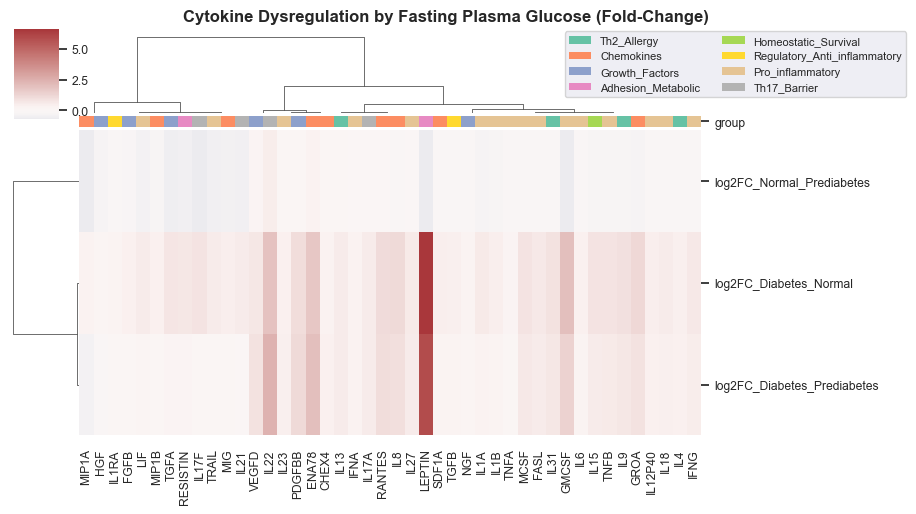

In [134]:
sns.set_theme(font_scale=.8)
# Create a color palette
palette = sns.color_palette("Set2", len(set(cytokine_groups_df.loc[fpg_cyt_sig])))
lut = dict(zip(set(cytokine_groups_df.loc[fpg_cyt_sig]), palette))

g = sns.clustermap(fpg_cyt.loc[fpg_cyt_sig].filter(like='log2').T, metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5), 
               dendrogram_ratio = (.1, .2),
               col_colors=pd.Series(cytokine_groups_df.loc[fpg_cyt_sig]).map(lut))
for label in lut:
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc=(0.78,0.2), ncol=2, fontsize=8)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=8.7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8.7)
plt.suptitle('Cytokine Dysregulation by Fasting Plasma Glucose (Fold-Change)', fontsize=12, fontweight='bold', y=1.02)
plt.savefig('imgs/cytokine_dysregulation_fpg.png', bbox_inches='tight', dpi=300);

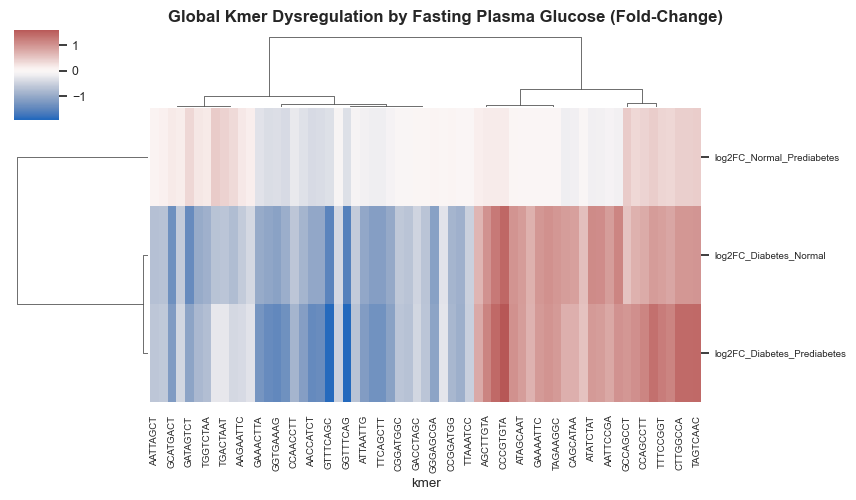

In [135]:
sns.set_theme(font_scale=.8)
g = sns.clustermap(fpg_kmer_site.loc[fpg_kmer_sig].filter(regex='log2').reset_index(names='kmer').groupby(['kmer']).mean().T, metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5))
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=7)
plt.suptitle('Global Kmer Dysregulation by Fasting Plasma Glucose (Fold-Change)', fontsize=12, fontweight='bold', y=1.02);

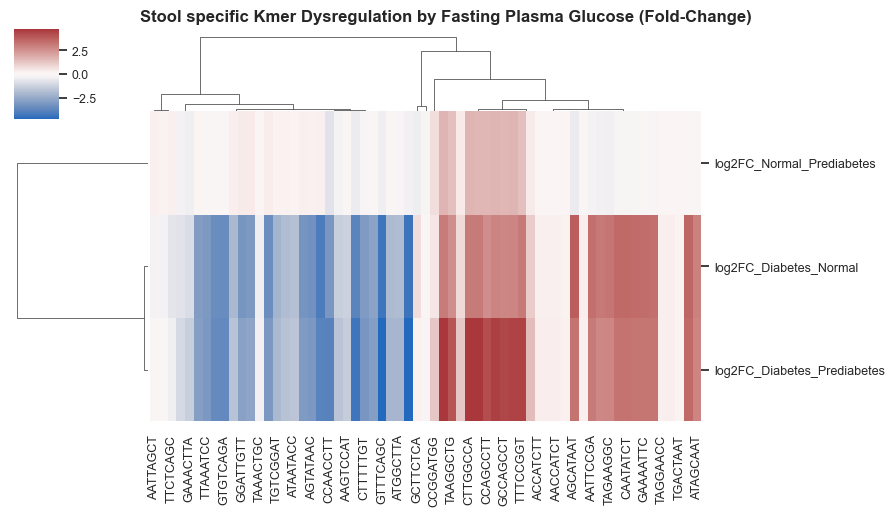

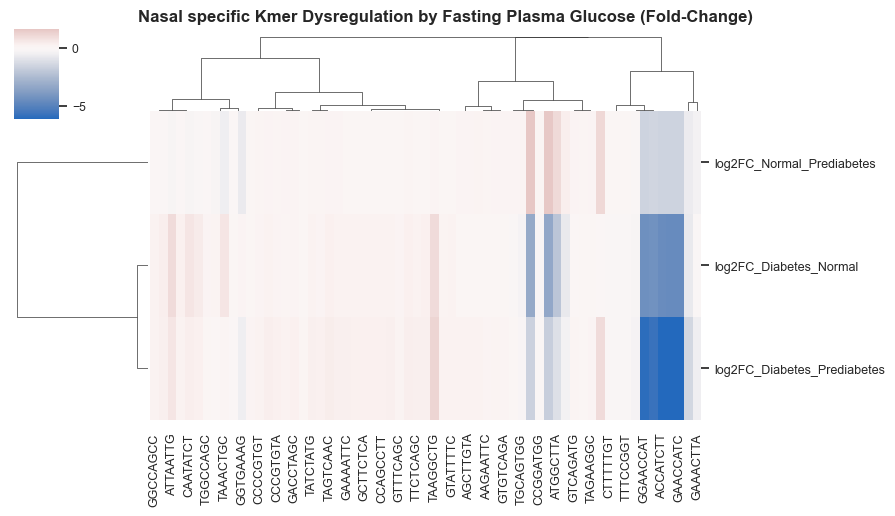

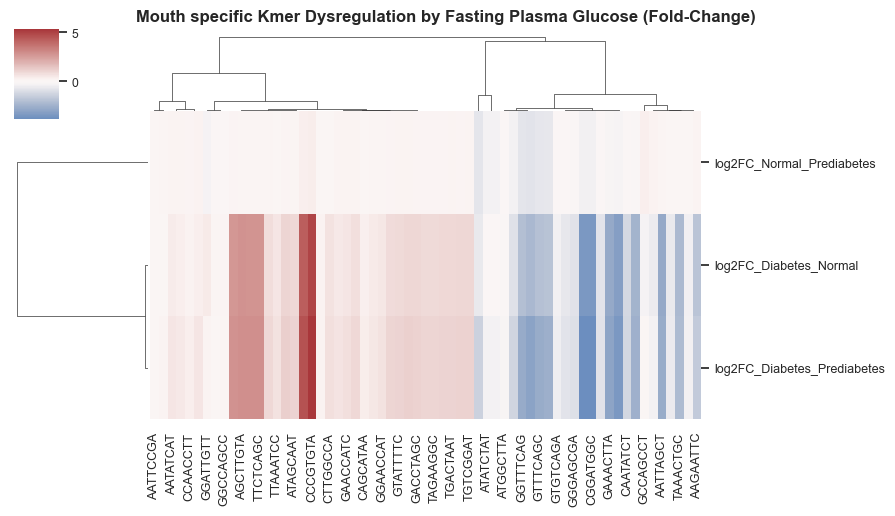

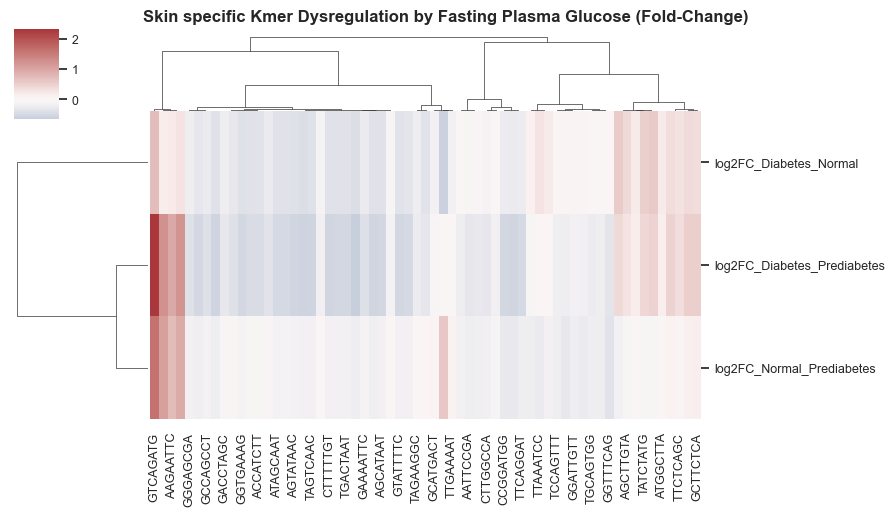

In [136]:
sns.set_theme(font_scale=.8)
for i in sites:
    g = sns.clustermap(fpg_kmer_site.loc[fpg_kmer_sig].query(f'key=="{i}"').filter(like='log2').T, metric='correlation', 
                method='complete', cmap='vlag', center=0,figsize=(9,5))
    # Reduce font size for tick labels
    g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=9)
    g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=9)
    plt.suptitle(f'{i} specific Kmer Dysregulation by Fasting Plasma Glucose (Fold-Change)', fontsize=12, fontweight='bold', y=1.02)
    plt.savefig(f'imgs/{i}_Dysregulation_fpg.png', dpi=250);

## __Interaction__

__Age vs Gender, BMI Group, and FPG__

In [137]:
# Age
age_sex_cyt = test_interaction(cytokine_df, target, ['age_gp', 'Gender'])
age_bmi_cyt = test_interaction(cytokine_df, target, ['age_gp', 'BMI_group'])
age_fpg_cyt = test_interaction(cytokine_df, target, ['age_gp', 'FPG_class'])

In [138]:
age_sex_kmer = pd.concat([test_interaction(kmer_data.query(f'site == "{site}"'), sig_kmers, ['age_gp', 'Gender']).assign(key=site) for site in sites])
age_bmi_kmer = pd.concat([test_interaction(kmer_data.query(f'site == "{site}"'), sig_kmers, ['age_gp', 'BMI_group']).assign(key=site) for site in sites])
age_fpg_kmer = pd.concat([test_interaction(kmer_data.query(f'site == "{site}"'), sig_kmers, ['age_gp', 'FPG_class']).assign(key=site) for site in sites])

In [139]:
age_sex_kmer.query('qval < 0.05 & eta_sq >= 0.06').groupby('key').size()

key
Mouth    22
Nasal     2
Stool    60
dtype: int64

In [140]:
age_fpg_kmer.query('qval < 0.05 & eta_sq >= 0.06').groupby('key').size()

key
Mouth    30
Nasal    58
Skin      4
Stool    79
dtype: int64

In [141]:
age_bmi_kmer.query('qval < 0.05 & eta_sq >= 0.06').groupby('key').size()

key
Mouth     23
Nasal     31
Skin      21
Stool    122
dtype: int64

In [142]:
age_sex_kmer.query('qval < 0.05 & eta_sq >= 0.06').index.nunique()

79

In [143]:
# sigifican cytokines and kmers by age & fpg
age_fpg_cyt_sig = age_fpg_cyt.query('qval < 0.05 & eta_sq >= 0.06').index
age_fpg_kmer_sig = age_fpg_kmer.query('qval < 0.05 & eta_sq >= 0.06').index.unique()

len(age_fpg_cyt_sig), len(age_fpg_kmer_sig)

(28, 145)

In [144]:
# sigifican cytokines and kmers by age & bmi
age_bmi_cyt_sig = age_bmi_cyt.query('qval < 0.05 & eta_sq >= 0.06').index
age_bmi_kmer_sig = age_bmi_kmer.query('qval < 0.05 & eta_sq >= 0.06').index.unique()

len(age_bmi_cyt_sig), len(age_bmi_kmer_sig)

(23, 163)

In [145]:
age_sex_cyt_sig = age_sex_cyt.query('qval < 0.05 & eta_sq >= 0.06').index
age_sex_cyt_sig

Index(['EOTAXIN', 'IL17A', 'RANTES', 'GMCSF', 'MCP1', 'VEGFD', 'PAI1',
       'ENA78'],
      dtype='object')

In [146]:
age_fpg_cyt_sig

Index(['IL17F', 'TGFA', 'MIP1A', 'LIF', 'IL1B', 'IL2', 'IL5', 'IFNB',
       'EOTAXIN', 'IL12P70', 'GMCSF', 'HGF', 'MCP1', 'VEGFD', 'TRAIL', 'GCSF',
       'IL12P40', 'MCP3', 'MIG', 'IL21', 'PDGFBB', 'VEGF', 'LEPTIN', 'PAI1',
       'CD40L', 'CHEX1', 'CHEX2', 'CHEX3'],
      dtype='object')

In [147]:
age_bmi_cyt_sig

Index(['IL17F', 'MIP1A', 'IL2', 'IL5', 'IL7', 'IFNB', 'EOTAXIN', 'IL12P70',
       'IL31', 'IL1RA', 'RANTES', 'MCP1', 'VEGFD', 'NGF', 'GCSF', 'IL23',
       'IL12P40', 'MIG', 'FGFB', 'PDGFBB', 'VEGF', 'ENA78', 'CHEX4'],
      dtype='object')

In [148]:
age_sex_cyt_sig.intersection(age_fpg_cyt_sig), age_sex_cyt_sig.intersection(age_bmi_cyt_sig)

(Index(['EOTAXIN', 'GMCSF', 'MCP1', 'VEGFD', 'PAI1'], dtype='object'),
 Index(['EOTAXIN', 'RANTES', 'MCP1', 'VEGFD', 'ENA78'], dtype='object'))

In [149]:
age_sex_cyt_sig.intersection(age_fpg_cyt_sig.union(age_bmi_cyt_sig)), age_fpg_cyt_sig.intersection(age_bmi_cyt_sig)

(Index(['EOTAXIN', 'RANTES', 'GMCSF', 'MCP1', 'VEGFD', 'PAI1', 'ENA78'], dtype='object'),
 Index(['IL17F', 'MIP1A', 'IL2', 'IL5', 'IFNB', 'EOTAXIN', 'IL12P70', 'MCP1',
        'VEGFD', 'GCSF', 'IL12P40', 'MIG', 'PDGFBB', 'VEGF'],
       dtype='object'))

In [150]:
# perform pairwise comparison (Post Hoc) test
cyt_age_fpg_int = parallel_compute(partial(kw_dunn_interactions, cytokine_df, group_col=['age_gp', 'FPG_class']), age_fpg_cyt_sig)
kmer_age_fpg_int = parallel_compute(partial(kw_dunn_interactions, kmer_data, group_col=['age_gp', 'FPG_class']), age_fpg_kmer_sig)

In [151]:
cyt_age_bmi_int = parallel_compute(partial(kw_dunn_interactions, cytokine_df, group_col=['age_gp', 'BMI_group']), age_bmi_cyt_sig)
kmer_age_bmi_int = parallel_compute(partial(kw_dunn_interactions, kmer_data, group_col=['age_gp', 'BMI_group']), age_bmi_kmer_sig)

In [152]:
kmer_age_fpg_int.groupby(['gp']).significant_pairs.apply(lambda x: ' '.join(x).replace(',', '').split()).apply(np.unique).apply(lambda x: ', '.join(x))

gp
FPG_class: Normal         Middle-aged-Senior, Middle-aged-Young, Senior-...
FPG_class: Prediabetes    Middle-aged-Senior, Middle-aged-Young, Senior-...
age_gp: Middle-aged       Diabetes-Normal, Diabetes-Prediabetes, Normal-...
age_gp: Senior                                           Normal-Prediabetes
age_gp: Young                                            Normal-Prediabetes
Name: significant_pairs, dtype: object

In [153]:
kmer_age_bmi_int.groupby(['gp']).significant_pairs.apply(lambda x: ' '.join(x).replace(',', '').split()).apply(np.unique).apply(lambda x: ', '.join(x))

gp
BMI_group: normal        Middle-aged-Senior, Middle-aged-Young, Senior-...
BMI_group: obese         Middle-aged-Senior, Middle-aged-Young, Senior-...
BMI_group: overweight    Middle-aged-Senior, Middle-aged-Young, Senior-...
age_gp: Middle-aged      normal-obese, normal-overweight, obese-overweight
age_gp: Senior           normal-obese, normal-overweight, obese-overweight
age_gp: Young            normal-obese, normal-overweight, obese-overweight
Name: significant_pairs, dtype: object

- **sex vs bmi, fpg**

In [154]:
sex_bmi_cyt = test_interaction(cytokine_df, target, ['Gender', 'BMI_group'])
sex_fpg_cyt = test_interaction(cytokine_df, target, ['Gender', 'FPG_class'])

In [155]:
sex_bmi_kmer = pd.concat([test_interaction(kmer_data.query(f'site == "{site}"'), sig_kmers, ['Gender', 'BMI_group']).assign(key=site) for site in sites])
sex_fpg_kmer = pd.concat([test_interaction(kmer_data.query(f'site == "{site}"'), sig_kmers, ['Gender', 'FPG_class']).assign(key=site) for site in sites])

In [156]:
sex_fpg_kmer.query('qval < 0.05 & eta_sq >= 0.06').key.value_counts()

key
Mouth    201
Stool    180
Nasal     55
Skin       2
Name: count, dtype: int64

In [157]:
sex_bmi_kmer.query('qval < 0.05 & eta_sq >= 0.06').key.value_counts()

key
Stool    48
Mouth    43
Nasal     9
Name: count, dtype: int64

In [158]:
sex_fpg_cyt_sig = sex_fpg_cyt.query('qval < 0.05 & eta_sq >= 0.06').index
sex_fpg_kmer_sig = sex_fpg_kmer.query('qval < 0.05 & eta_sq >= 0.06').index.unique()

len(sex_fpg_cyt_sig), len(sex_fpg_kmer_sig)

(8, 253)

In [159]:
sex_bmi_cyt_sig = sex_bmi_cyt.query('qval < 0.05 & eta_sq >= 0.06').index
sex_bmi_kmer_sig = sex_bmi_kmer.query('qval < 0.05 & eta_sq >= 0.06').index.unique()

len(sex_bmi_cyt_sig), len(sex_bmi_kmer_sig)

(3, 90)

In [160]:
sex_bmi_cyt_sig, sex_fpg_cyt_sig

(Index(['IL2', 'IL5', 'ICAM1'], dtype='object'),
 Index(['MIP1A', 'GMCSF', 'MCP1', 'VCAM1', 'PAI1', 'CHEX1', 'CHEX2', 'CHEX3'], dtype='object'))

In [161]:
cyt_sex_fpg_int = parallel_compute(partial(kw_dunn_interactions, cytokine_df, group_col=['Gender', 'FPG_class']), sex_fpg_cyt_sig)
kmer_sex_fpg_int = parallel_compute(partial(kw_dunn_interactions, kmer_data, group_col=['Gender', 'FPG_class']), sex_fpg_kmer_sig)

In [162]:
cyt_sex_bmi_int = parallel_compute(partial(kw_dunn_interactions, cytokine_df, group_col=['Gender', 'BMI_group']), sex_bmi_cyt_sig)
kmer_sex_bmi_int = parallel_compute(partial(kw_dunn_interactions, kmer_data, group_col=['Gender', 'BMI_group']), sex_bmi_kmer_sig)

In [163]:
kmer_sex_bmi_int.groupby(['gp']).significant_pairs.apply(lambda x: ' '.join(x).replace(',', '').split()).apply(np.unique).apply(lambda x: ', '.join(x))

gp
BMI_group: normal                                                      F-M
BMI_group: obese                                                       F-M
BMI_group: overweight                                                  F-M
Gender: F                normal-obese, normal-overweight, obese-overweight
Gender: M                normal-obese, normal-overweight, obese-overweight
Name: significant_pairs, dtype: object

In [164]:
kmer_sex_fpg_int.groupby(['gp']).significant_pairs.apply(lambda x: ' '.join(x).replace(',', '').split()).apply(np.unique).apply(lambda x: ', '.join(x))

gp
FPG_class: Normal                                                       F-M
FPG_class: Prediabetes                                                  F-M
Gender: F                                                Normal-Prediabetes
Gender: M                 Diabetes-Normal, Diabetes-Prediabetes, Normal-...
Name: significant_pairs, dtype: object

In [165]:
[cytokine_df[i].value_counts() for i in cytokine_df.filter(regex='Gen|BMI_|FPG|age_gp').columns]

[FPG_class
 Normal         463
 Prediabetes    128
 Diabetes        79
 Name: count, dtype: int64,
 Gender
 M    389
 F    281
 Name: count, dtype: int64,
 age_gp
 Senior         292
 Middle-aged    279
 Young           99
 Name: count, dtype: int64,
 BMI_group
 overweight    265
 normal        209
 obese         196
 Name: count, dtype: int64]

- **FPG vs BMI**

In [166]:
bmi_fpg_cyt = test_interaction(cytokine_df, target, ['BMI_group', 'FPG_class'])
bmi_fpg_kmer = pd.concat([test_interaction(kmer_data.query(f'site == "{site}"'), sig_kmers, ['BMI_group', 'FPG_class']).assign(key=site) for site in sites])

In [167]:
bmi_fpg_kmer.query('qval < 0.05 & eta_sq >= 0.06').key.value_counts()

key
Nasal    100
Stool     39
Mouth     27
Skin      14
Name: count, dtype: int64

In [168]:
bmi_fpg_cyt_sig = bmi_fpg_cyt.query('qval < 0.05 & eta_sq >= 0.06').index
bmi_fpg_kmer_sig = bmi_fpg_kmer.query('qval < 0.05 & eta_sq >= 0.06').index.unique()

len(bmi_fpg_cyt_sig), len(bmi_fpg_kmer_sig)

(14, 151)

In [169]:
bmi_fpg_cyt_sig

Index(['IL17F', 'TGFA', 'IL2', 'IFNB', 'EOTAXIN', 'IL1RA', 'GMCSF', 'HGF',
       'IL12P40', 'RESISTIN', 'VEGF', 'LEPTIN', 'CD40L', 'CHEX2'],
      dtype='object')

In [170]:
cyt_bmi_fpg_int = parallel_compute(partial(kw_dunn_interactions, cytokine_df, group_col=['BMI_group', 'FPG_class']), target)
kmer_bmi_fpg_int = parallel_compute(partial(kw_dunn_interactions, kmer_data, group_col=['BMI_group', 'FPG_class']), sig_kmers)

In [171]:
kmer_bmi_fpg_int.groupby(['gp']).significant_pairs.apply(lambda x: ' '.join(x).replace(',', '').split()).apply(np.unique).apply(lambda x: ', '.join(x))

gp
BMI_group: normal         Diabetes-Normal, Diabetes-Prediabetes, Normal-...
BMI_group: obese                                         Normal-Prediabetes
BMI_group: overweight                                    Normal-Prediabetes
FPG_class: Normal         normal-obese, normal-overweight, obese-overweight
FPG_class: Prediabetes    normal-obese, normal-overweight, obese-overweight
Name: significant_pairs, dtype: object

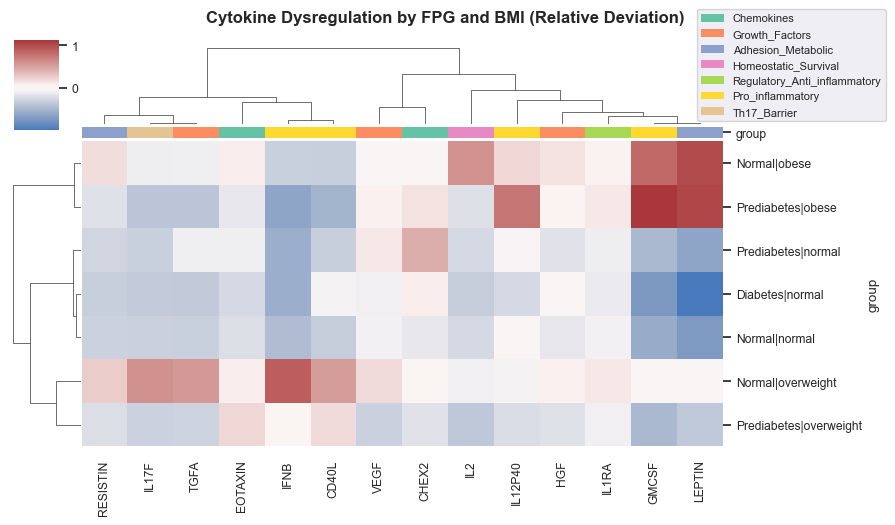

In [172]:
sns.set_theme(font_scale=.8)
# Create a color palette
palette = sns.color_palette("Set2", len(set(cytokine_groups_df.loc[bmi_fpg_cyt_sig])))
lut = dict(zip(set(cytokine_groups_df.loc[bmi_fpg_cyt_sig]), palette))

g = sns.clustermap(group_mean_matrix(cytokine_df, bmi_fpg_cyt_sig, 'FPG_class:BMI_group'), metric='correlation', 
               method='complete', cmap='vlag', center=0,figsize=(9,5), 
               dendrogram_ratio = (.1, .2),
               col_colors=pd.Series(cytokine_groups_df.loc[bmi_fpg_cyt_sig]).map(lut))
for label in lut:
    g.ax_col_dendrogram.bar(0, 0, color=lut[label],
                            label=label, linewidth=0)
g.ax_col_dendrogram.legend(loc=(0.96,0.03), ncol=1, fontsize=8)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=8.7)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=8.7)

plt.suptitle('Cytokine Dysregulation by FPG and BMI (Relative Deviation)', fontsize=12, fontweight='bold', y=1.04)
plt.savefig('imgs/cytokine_dysregulation_fpg_bmi.png', bbox_inches='tight', dpi=300);

In [173]:
# compare group deviations with reference group, if given
fpg_bmi_gp_compare = compare_group_mean_matrix(group_mean_matrix(cytokine_df, bmi_fpg_cyt_sig, 'FPG_class:BMI_group'), 'Normal|normal')

In [174]:
# replace the middle | with -
fpg_bmi_gp_compare.index = fpg_bmi_gp_compare.index.str.replace(r'^([^|]*\|[^|]*)\|', r'\1-', regex=True)

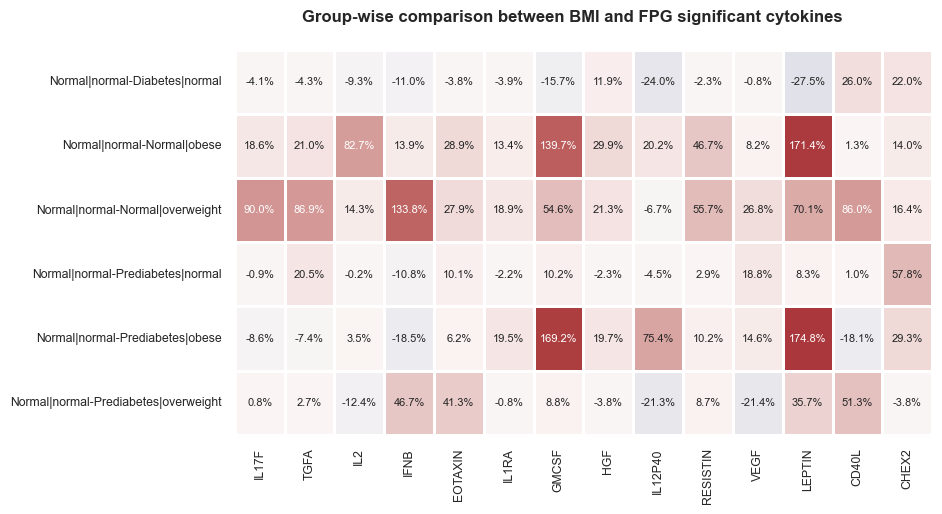

In [175]:
plt.figure(figsize=(9,5))
sns.heatmap(fpg_bmi_gp_compare, cmap='vlag', center=0, annot=True, cbar=False, fmt='.1%', linecolor='w', lw=1, annot_kws={'fontsize':8})
plt.suptitle('Group-wise comparison between BMI and FPG significant cytokines', fontsize=12, fontweight='bold', y=0.96)
plt.savefig('imgs/cytokine_dysregulation_fpg_bmi_pairwise_compare.png', dpi=200, bbox_inches='tight');

---

### How do these kmer sequences at site-levels affect cytokine levels?

Here, we will want to estimate the effects of individual significant global kmers on cytokine levels at the different body sites. To prevent spurious effects, we would adjust this by gender, age group, bmi group, fpg, and the interactions between age and gender, age and fpg, gender and bmi, and gender and fpg. We will also check this at the global level by also adjusting for site differences

In [176]:
# merge cytokine and kmer data into one
merged_data = kmer_data[['ID','SampleID','site']+sig_kmers.tolist()].merge(
    cytokine_df[['SampleID', 'Gender', 'age_gp', 'BMI_group', 'FPG_class']+target.tolist()], on='SampleID').set_index(['ID', 'SampleID'])

In [177]:
# Define the wrapper function
def process_kmer_lr(df, kmer, cytokines):
    func = map(partial(fit_regression_model, df, kmer=kmer), cytokines)
    res = pd.concat(list(func))
    res = res.reset_index().rename(columns={'index': 'cyt'})
    return res.set_index(['cyt', 'name'])

In [178]:
# Run in parallel
# Prepare all (site, kmer) pairs
tasks = [kmer for kmer in sig_kmers]

global_kmer_data = merged_data.groupby('SampleID')[sig_kmers].mean().merge(
    cytokine_df.set_index('SampleID')[target.tolist()+['age_gp', 'BMI_group', 'Gender', 'FPG_class']], on='SampleID')

global_regression_results = Parallel(n_jobs=3)(
    delayed(process_kmer_lr)(global_kmer_data, kmer, target) for kmer in tqdm(tasks)
)
# Combine all results
global_regression_results = pd.concat(global_regression_results, axis=1).reset_index()

100%|██████████| 262/262 [07:15<00:00,  1.66s/it]


In [179]:
# move cytokines to columns and kmers to rows
global_regression_results = (
    global_regression_results
    .melt(id_vars=['cyt', 'name'], var_name='kmer')
    .pivot(index=['kmer', 'name'], columns='cyt', values='value')
    .reset_index(level=[1])
)

In [180]:
global_regression_results.head()

cyt,name,BDNF,CD40L,CHEX1,CHEX2,CHEX3,CHEX4,EGF,ENA78,EOTAXIN,...,SCF,SDF1A,TGFA,TGFB,TNFA,TNFB,TRAIL,VCAM1,VEGF,VEGFD
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAGAAT,coef,0.038330,0.020397,-0.024161,0.048831,1.131667e-01,0.038094,0.000807,-0.033299,-0.016938,...,0.000152,0.109706,0.021194,0.062834,0.100210,0.031939,0.127122,0.061710,0.091495,0.042222
AAAAGAAT,pval,0.261504,0.542038,0.480607,0.177800,1.857911e-03,0.265219,0.982373,0.233945,0.599226,...,0.996559,0.001632,0.549237,0.058876,0.004308,0.354721,0.000237,0.087152,0.008320,0.166977
AAACGGAT,coef,0.041428,-0.010426,-0.027488,0.091485,1.817259e-01,-0.002957,0.035241,-0.050225,0.008118,...,0.007513,0.016531,-0.078357,0.022065,0.075781,-0.024446,0.052190,0.059245,0.031401,0.027005
AAACGGAT,pval,0.151081,0.712448,0.342536,0.002754,2.387986e-09,0.918586,0.253751,0.033525,0.765809,...,0.801252,0.575940,0.008659,0.433223,0.010727,0.402208,0.075414,0.052027,0.285225,0.295999
AAACTTTA,coef,-0.077248,-0.044699,0.006556,0.047647,3.544949e-02,-0.192282,-0.113964,0.021167,0.030180,...,-0.141179,-0.068847,0.027452,-0.016365,-0.053078,-0.128466,-0.082820,-0.085656,-0.100567,-0.083034


In [181]:
global_regression_results.to_csv('../data/global_regression_results.csv')

In [ ]:
# Run in parallel
# Prepare all (site, kmer) pairs
tasks = [kmer for kmer in sig_kmers]

site_results = []

for site in tqdm(sites, desc='Linear Regression Model for kmers and cytokines'):
    regression_results = Parallel(n_jobs=2)(
        delayed(process_kmer_lr)(merged_data.query(f'site=="{site}"'), kmer, target) for kmer in tasks
    )
    # Combine all results
    regression_results = pd.concat(regression_results, axis=1).reset_index().assign(site = site)
    site_results.append(regression_results)

site_results = pd.concat(site_results)

Linear Regression Model for kmers and cytokines:  25%|██▌       | 1/4 [11:24<34:12, 684.18s/it]

In [ ]:
# move cytokines to columns and kmers to rows
site_results = (
    site_results
    .melt(id_vars=['cyt', 'name', 'site'], var_name='kmer')
    .pivot(index=['kmer', 'name', 'site'], columns='cyt', values='value')
    .reset_index(level=[1,2])
)

In [ ]:
site_results.head()

cyt,name,site,BDNF,CD40L,CHEX1,CHEX2,CHEX3,CHEX4,EGF,ENA78,...,SCF,SDF1A,TGFA,TGFB,TNFA,TNFB,TRAIL,VCAM1,VEGF,VEGFD
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAGAAT,coef,Mouth,0.087525,0.050240,0.005801,0.070446,0.063636,0.097067,0.096812,0.092458,...,0.068805,0.111999,-0.012449,0.038368,0.069938,0.048510,0.114191,0.036263,0.133975,0.026162
AAAAGAAT,coef,Nasal,0.133132,0.138010,0.027182,0.013036,0.017116,0.059904,0.066261,-0.028075,...,0.109573,0.188191,0.131381,0.119055,0.148913,0.171891,0.191755,0.018271,0.191273,0.014171
AAAAGAAT,coef,Skin,0.050860,-0.038458,-0.196578,-0.017538,0.111229,-0.024983,-0.021740,-0.015949,...,-0.023801,0.041486,-0.160243,0.017867,0.046939,0.006132,0.043013,0.067109,0.016212,-0.040459
AAAAGAAT,coef,Stool,-0.021138,0.007750,0.053954,-0.002949,0.020586,0.025338,0.009857,-0.018744,...,-0.007919,0.021075,0.062309,0.017888,0.036417,0.025441,0.009540,0.000119,0.031873,0.015283
AAAAGAAT,pval,Mouth,0.073113,0.301911,0.906315,0.169360,0.220041,0.049838,0.062280,0.023060,...,0.173681,0.026878,0.808028,0.424693,0.170726,0.333285,0.022895,0.485123,0.006465,0.532435


In [ ]:
site_results.to_csv('../data/body_site_regression_results.csv')

In [ ]:
# number of significant kmers for each cytokine at the global level
global_regression_results.query('name == "pval"').select_dtypes(np.number).apply(lambda x: multipletests(x, method='fdr_bh')[0], axis=0).sum(0)

cyt
BDNF      48
CD40L     19
CHEX1     15
CHEX2     61
CHEX3    144
        ... 
TNFB      40
TRAIL    120
VCAM1     73
VEGF      70
VEGFD     74
Length: 66, dtype: int64

In [ ]:
# number of cytokines a kmer has signficant effect on at the global level
global_regression_results.query('name == "pval"').select_dtypes(np.number).apply(lambda x: multipletests(x, method='fdr_bh')[0], axis=0).sum(1)

kmer
AAAAGAAT    13
AAACGGAT    12
AAACTTTA    32
AAAGCCCG    10
AAAGCGGG    13
            ..
TTGACGGA    12
TTGAGAAA    33
TTTCCGGT    36
TTTTGAAC    23
TTTTTCTT     6
Length: 262, dtype: int64

In [ ]:
site_sig_kmer_res = []
for site in sites:
    res = site_results.query('name == "pval"').query(f'site == "{site}"').select_dtypes('number').apply(lambda x: multipletests(x, method='fdr_bh')[0]).sum(0)
    res.name = site
    site_sig_kmer_res.append(res)

site_sig_kmer_res = pd.concat(site_sig_kmer_res, axis=1)

In [ ]:
site_sig_cyt_res = []
for site in sites:
    res = site_results.query('name == "pval"').query(f'site == "{site}"').select_dtypes('number').apply(lambda x: multipletests(x, method='fdr_bh')[0]).sum(1)
    res.name = site
    site_sig_cyt_res.append(res)

site_sig_cyt_res = pd.concat(site_sig_cyt_res, axis=1)

In [ ]:
# number of significant kmers and cytokines with |coefficient| > 0.15
mask1 = global_regression_results.query('name == "pval"').select_dtypes(np.number).apply(lambda x: multipletests(x, alpha=0.01, method='fdr_bh')[0], axis=0)
mask2 = global_regression_results.query('name == "coef"').select_dtypes(np.number).apply(lambda x: abs(x) >= 0.15)

sig_cyt_model = global_regression_results.columns[1:][(np.sum(mask1 & mask2, axis=0) > 0).values] # select those with qval < 0.05 and |coef| >= 0.2
sig_kmer_model = global_regression_results.query('name=="coef"').loc[(np.sum(mask1 & mask2, axis=1) > 0).values].index # select those with qval < 0.05 and |coef| >= 0.2

In [ ]:
len(sig_cyt_model), len(sig_kmer_model)

(57, 139)

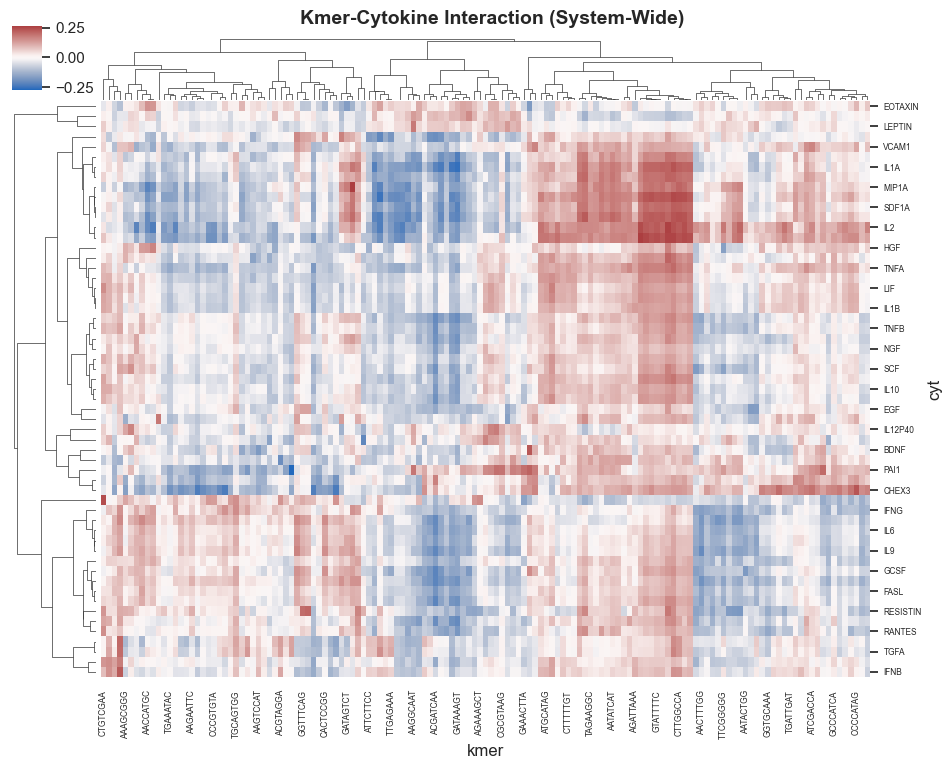

In [ ]:
ref_fig = sns.clustermap(global_regression_results.query('name == "coef"').loc[sig_kmer_model, sig_cyt_model].T, method='complete', 
               metric='correlation', cmap='vlag', center=0, figsize=(10,8),cbar_pos=(0.02, 0.91, 0.03, 0.08), 
               dendrogram_ratio=(0.1, 0.1))

# Reduce font size for tick labels
ref_fig.ax_heatmap.set_xticklabels(ref_fig.ax_heatmap.get_xticklabels(), fontsize=6)
ref_fig.ax_heatmap.set_yticklabels(ref_fig.ax_heatmap.get_yticklabels(), fontsize=6)

# Optional: rotate x-axis labels for readability
plt.setp(ref_fig.ax_heatmap.get_xticklabels(), rotation=90)
plt.suptitle('Kmer-Cytokine Interaction (System-Wide)', fontsize=14, fontweight='bold', y=1.01)
plt.savefig(f'imgs/global_kmer_cyt_clustermap.png');

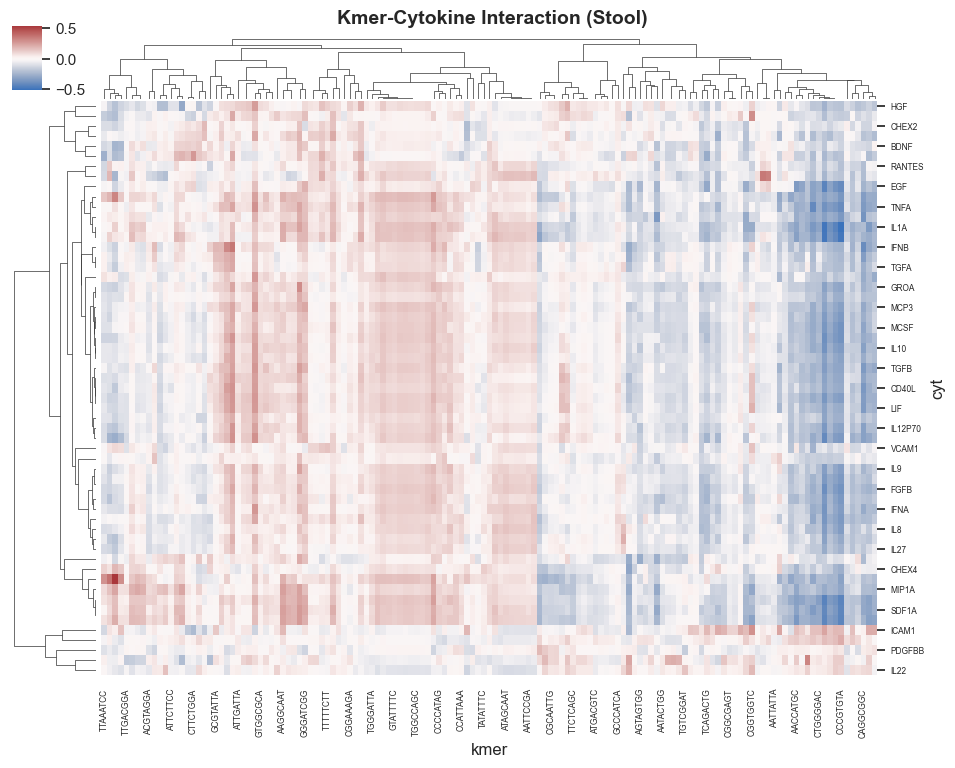

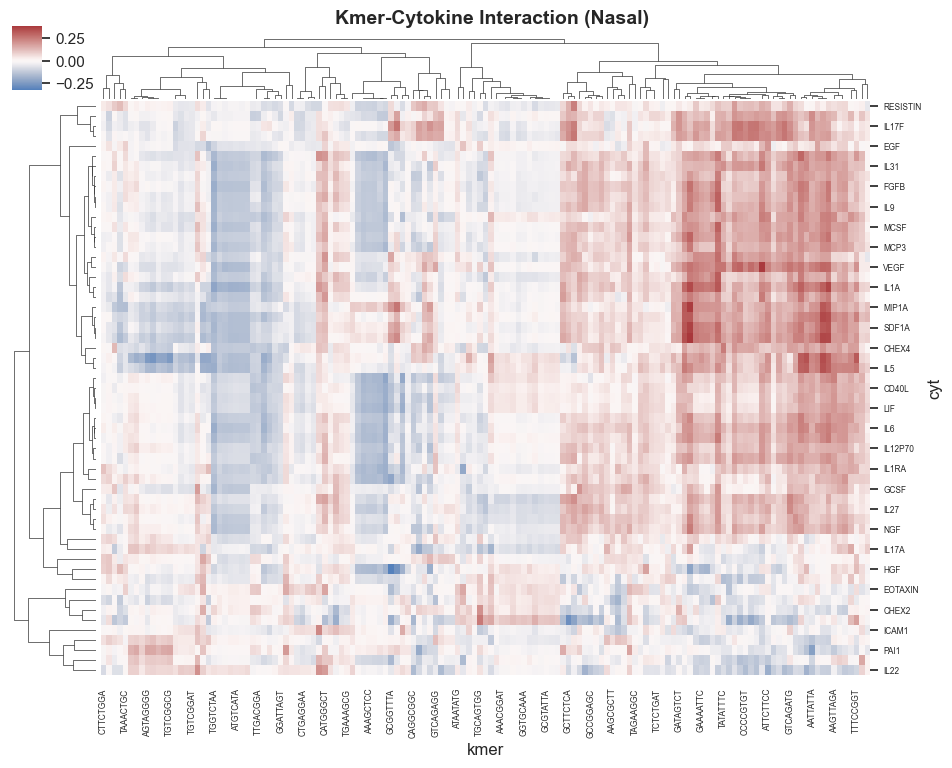

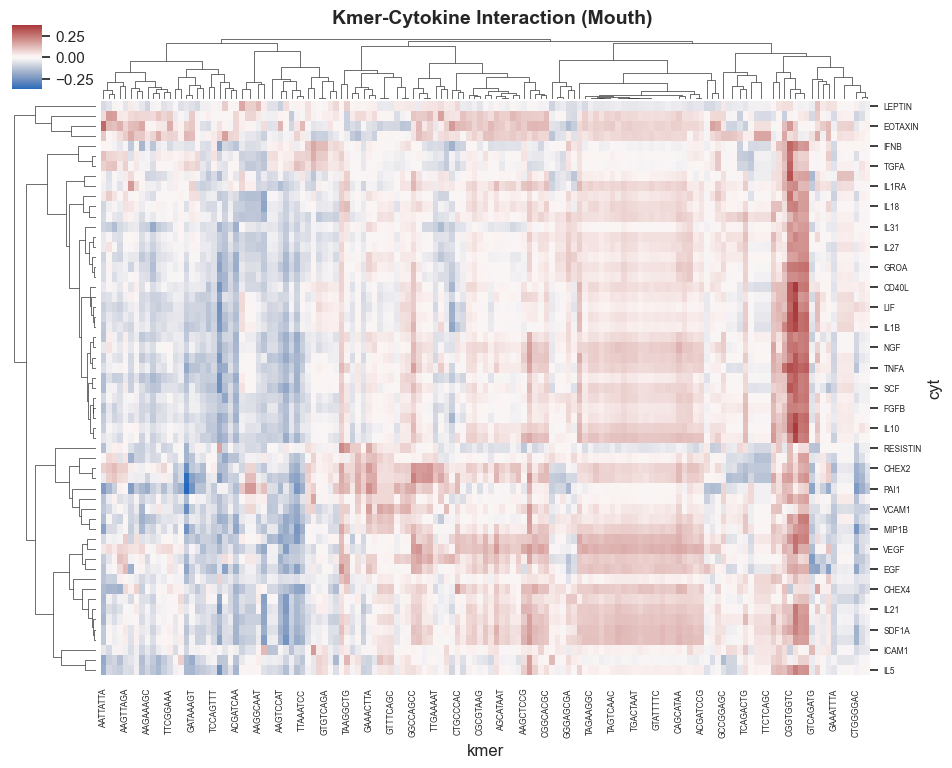

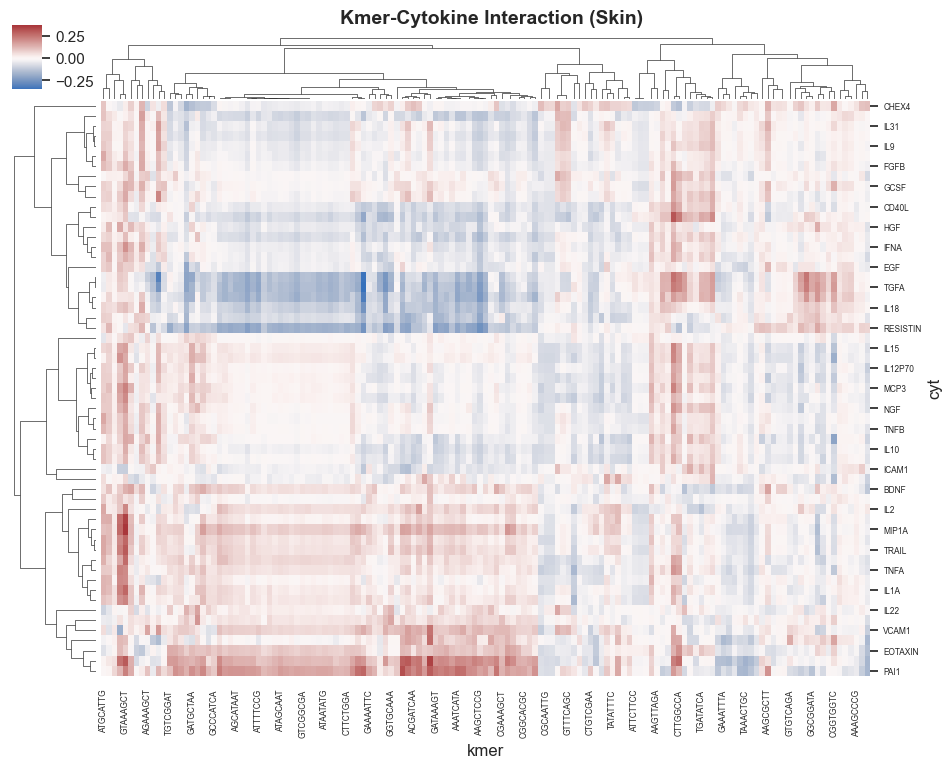

In [ ]:
for site in sites:
    ref_fig = sns.clustermap(site_results.query(f'name == "coef" & site == "{site}"').loc[sig_kmer_model, sig_cyt_model].T, method='complete', 
                metric='correlation', cmap='vlag', center=0, figsize=(10,8),cbar_pos=(0.02, 0.91, 0.03, 0.08), 
                dendrogram_ratio=(0.1, 0.1))

    # Reduce font size for tick labels
    ref_fig.ax_heatmap.set_xticklabels(ref_fig.ax_heatmap.get_xticklabels(), fontsize=6)
    ref_fig.ax_heatmap.set_yticklabels(ref_fig.ax_heatmap.get_yticklabels(), fontsize=6)

    # Optional: rotate x-axis labels for readability
    plt.setp(ref_fig.ax_heatmap.get_xticklabels(), rotation=90)
    plt.suptitle(f'Kmer-Cytokine Interaction ({site.title()})', fontsize=14, fontweight='bold', y=1.01)
    plt.savefig(f'imgs/{site}_kmer_cyt_clustermap.png');

Proportion of kmers and kmers by positive and negative effects

In [ ]:
def filter_regression_result(res, alpha=0.05, coef_cutoff=None, p_adjust='fdr_bh'):
    coef_mask = None
    pval_mask = res.query('name == "pval"').select_dtypes('number').apply(lambda x: multipletests(x, alpha=0.05, method=p_adjust)[0])
    if coef_cutoff is not None:
        coef_mask = res.query('name == "coef"').select_dtypes('number').apply(lambda x: abs(x) >= coef_cutoff)
    mask = pval_mask & coef_mask if coef_mask is not None else pval_mask
    return res.query('name == "coef"').select_dtypes('number')[mask]

In [ ]:
a = filter_regression_result(global_regression_results).apply(lambda x: x <= -0.1).mean(0)*100
b = filter_regression_result(global_regression_results).apply(lambda x: x >= 0.1).mean(0)*100

In [ ]:
top_pos = b.nlargest(20)
top_neg = a.nlargest(20)

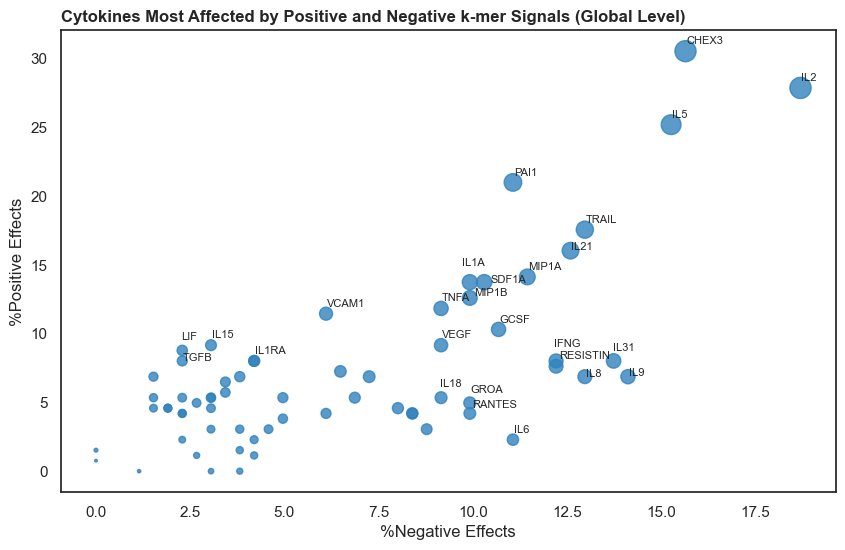

In [ ]:
sns.set_theme(style='white')
texts = []
plt.figure(figsize=(10,6))
ax = plt.scatter(a, b, color='#3182bd', s=5*(a+b), alpha=0.8)
plt.ylabel('%Positive Effects')
plt.xlabel('%Negative Effects')
for i, name in enumerate(top_pos.index.union(top_neg.index).unique()):
    texts.append(plt.text(a.loc[name], b.loc[name]+0.4, s=name, fontsize=8, fontweight=26))
adjust_text(texts)
plt.title('Cytokines Most Affected by Positive and Negative k-mer Signals (Global Level)', 
          fontsize=12, fontweight='bold', loc='left')
plt.grid(False)
plt.savefig('imgs/global_cytokine_pos_neg_kmer_signal.png');

- From the association test using spearman correlation, we have identified significant kmers and cytokines, for each group and site, that correlate with cytokines. Now, we want to test the effects of kmers on cytokines while adjusting for confounders (age, gender, FPG and BMI, with interactions such as age:gender, age:bmi, and gender:bmi). However, testing 1481 kmers on 66 cytokines to identify individual effects while adjusting for the confounders is computationally expensive. As a result, we will run a linear regression for each kmer and cytokine to select significant kmers (pvalues < 0.05). We will do this for each body site, and after that, we will select these kmers (a union or intersect) for downstream analysis.

In [ ]:
site_cyt_kmer_coef =  pd.concat([filter_regression_result(site_results.query(f'site == "{site}"'), coef_cutoff=0.15).assign(key=site) for site in sites])

In [ ]:
site_cyt_kmer_coef

cyt,BDNF,CD40L,CHEX1,CHEX2,CHEX3,CHEX4,EGF,ENA78,EOTAXIN,FASL,...,SDF1A,TGFA,TGFB,TNFA,TNFB,TRAIL,VCAM1,VEGF,VEGFD,key
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAGAAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stool
AAACGGAT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stool
AAACTTTA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stool
AAAGCCCG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.205904,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stool
AAAGCGGG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Stool
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTGACGGA,NaN,NaN,-0.214505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,-0.176704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Skin
TTGAGAAA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Skin
TTTCCGGT,NaN,NaN,-0.180498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Skin


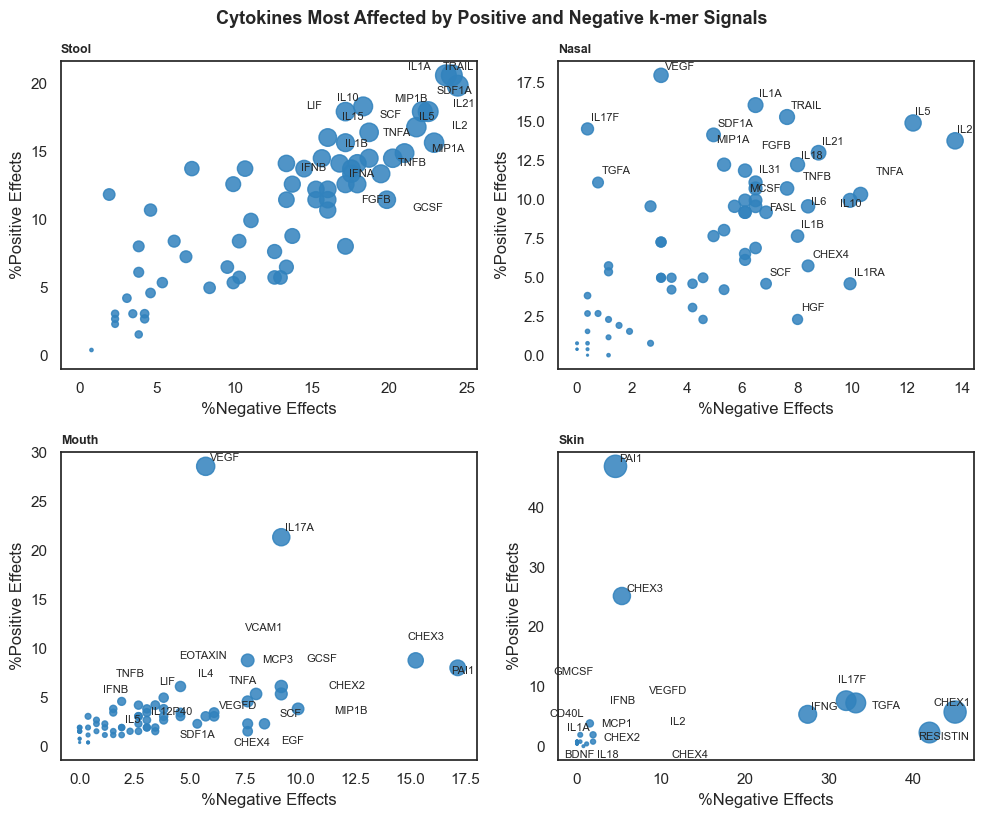

In [ ]:
sns.set_theme(style='white')
fig, axes = plt.subplots(2,2, figsize=(10,8))

for site, ax in zip(sites, axes.flat):
    site_filter = filter_regression_result(site_results.query(f'site == "{site}"'), coef_cutoff=0.1)
    a = site_filter.apply(lambda x: x <= -0.1).mean(0)*100
    b = site_filter.apply(lambda x: x >= 0.1).mean(0)*100
    top_pos = b.nlargest(15)
    top_neg = a.nlargest(15)

    texts = []
    ax.scatter(a, b, color='#3182bd', s=5*(a+b), alpha=0.85)
    ax.set_ylabel('%Positive Effects')
    ax.set_xlabel('%Negative Effects')
    for i, name in enumerate(top_pos.index.union(top_neg.index).unique()):
        text = ax.text(a.loc[name], b.loc[name]+0.4, s=name, fontsize=8, fontweight=26)
        texts.append(text)
    adjust_text(texts, ax=ax, pull_threshold=20, explode_radius=20, force_text=(1.2, 1.5))
    ax.set_title(f'{site.title()}', 
            fontsize=9, fontweight='bold', loc='left')
    plt.grid(False)
fig.tight_layout()
fig.suptitle(f'Cytokines Most Affected by Positive and Negative k-mer Signals', fontsize=13, fontweight='bold', y=1.02)
plt.savefig('imgs/cytokine_pos_neg_kmer_sigmal.png', dpi=300, bbox_inches='tight');